# Phase 2: Analysis


## Data Set Up
Combining data, basic data cleaning, and loading data.

In [180]:
# Needed setup/imports
import pandas as pd
import json
import os
import re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [181]:
# Load and combine all user data
base_path = "data"

all_history = []
all_playlists = []
all_library_tracks = []

for user_folder in os.listdir(base_path):
    user_path = os.path.join(base_path, user_folder)
    
    if not os.path.isdir(user_path):
        continue

    # Streaming data
    stream_files = glob(os.path.join(user_path, "StreamingHistory_music_*.json"))
    user_history = []

    for file in stream_files:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
            user_history.extend(data)

    if user_history:
        df_hist = pd.DataFrame(user_history)
        df_hist["user_id"] = user_folder
        all_history.append(df_hist)

    # Playlist data
    playlist_files = glob(os.path.join(user_path, "Playlist*.json"))
    playlist_tracks = []

    for file in playlist_files:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        playlists = data.get("playlists", data)

        for pl in playlists:
            items = pl.get("items", [])

            for item in items:
                track = item.get("track")

                # Handle missing tracks
                if not track or not isinstance(track, dict):
                    continue

                playlist_tracks.append({
                    "artistName": track.get("artistName"),
                    "trackName": track.get("trackName"),
                    "playlistName": pl.get("name"),
                    "user_id": user_folder
                })

    if playlist_tracks:
        df_pl = pd.DataFrame(playlist_tracks)
        all_playlists.append(df_pl)

    # Library data
    lib_path = os.path.join(user_path, "YourLibrary.json")

    if os.path.exists(lib_path):
        with open(lib_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        tracks = data.get("tracks", [])

        for t in tracks:
            all_library_tracks.append({
                "artistName": t.get("artist"),
                "trackName": t.get("track"),
                "user_id": user_folder
            })

# Combine all users data
if all_history:
    history_all = pd.concat(all_history, ignore_index=True)
else:
    raise ValueError("No streaming data found.")

if all_playlists:
    playlist_all = pd.concat(all_playlists, ignore_index=True)
else:
    playlist_all = pd.DataFrame(columns=["artistName", "trackName", "user_id"])

if all_library_tracks:
    library_tracks = pd.DataFrame(all_library_tracks)
else:
    library_tracks = pd.DataFrame(columns=["artistName", "trackName", "user_id"])

print("Streaming shape:", history_all.shape)
print("Playlist shape:", playlist_all.shape)
print("Library shape:", library_tracks.shape)

Streaming shape: (205849, 5)
Playlist shape: (18368, 4)
Library shape: (6851, 3)


### Data preprocessing
Clean and standardize text, preprocessing/feature engineering for analysis

#### Cleaning and Matching

In [182]:
# Cleaning and standardizing text
def clean_text(text):
    if pd.isna(text):
        return None
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9 ]", "", text)
    return text

# Applying cleaning
history_all["artist_clean"] = history_all["artistName"].apply(clean_text)
history_all["track_clean"] = history_all["trackName"].apply(clean_text)

playlist_all["artist_clean"] = playlist_all["artistName"].apply(clean_text)
playlist_all["track_clean"] = playlist_all["trackName"].apply(clean_text)

library_tracks["artist_clean"] = library_tracks["artistName"].apply(clean_text)
library_tracks["track_clean"] = library_tracks["trackName"].apply(clean_text)

# Create match keys
def create_match_key(df):
    return df["artist_clean"].fillna("") + "_" + df["track_clean"].fillna("")

history_all["match_key"] = create_match_key(history_all)
playlist_all["match_key"] = create_match_key(playlist_all)
library_tracks["match_key"] = create_match_key(library_tracks)

# Precompute sets of playlist and library keys for each user for faster lookup
playlist_keys = playlist_all.groupby("user_id")["match_key"].apply(set).to_dict()
library_keys = library_tracks.groupby("user_id")["match_key"].apply(set).to_dict()

# Time preprocessing
history_all["endTime"] = pd.to_datetime(history_all["endTime"])
history_all["hour"] = history_all["endTime"].dt.hour
history_all["day_of_week"] = history_all["endTime"].dt.day_name()
history_all["month"] = history_all["endTime"].dt.month

# Determine curation level
history_all["in_playlist"] = history_all.apply(
    lambda row: row["match_key"] in playlist_keys.get(row["user_id"], set()),
    axis=1)

history_all["in_library"] = history_all.apply(
    lambda row: row["match_key"] in library_keys.get(row["user_id"], set()),
    axis=1)

history_all["curation_level"] = (
    history_all["in_playlist"].astype(int) * 2 +
    history_all["in_library"].astype(int))

labels = {
    0: "not_curated",
    1: "library",
    2: "playlist",
    3: "both"}

history_all["curation_label"] = history_all["curation_level"].map(labels)

#### Aggregation and Preprocessing

In [183]:
# Aggregate by track and user
track_summary = (
    history_all
    .groupby(["user_id", "match_key"])
    .agg({
        "msPlayed": "sum",
        "trackName": "first",
        "artistName": "first",
        "curation_level": "max",
        "curation_label": "first",
        "hour": "mean"
    })
    .reset_index()
)

# Convert to minutes
track_summary["minutes_played"] = track_summary["msPlayed"] / 60000
history_all["minutes_played"] = history_all["msPlayed"] / 60000

# Quick sanity check for minute conversion
print("Total streaming events:", len(history_all))
print("Total minutes played:", round(history_all["minutes_played"].sum(), 2))

print("\nMinutes played summary:")
print(history_all["minutes_played"].describe())

# Adding playcount as metric
play_counts = (
    history_all
    .groupby(["user_id", "match_key"])
    .size()
    .reset_index(name="play_count")
)

track_summary = track_summary.merge(
    play_counts,
    on=["user_id", "match_key"],
    how="left"
)

# Load and prepare track metadata
track_meta = pd.read_csv("data/track_data.csv")

track_meta["artist_clean"] = track_meta["artists"].apply(clean_text)
track_meta["track_clean"] = track_meta["track_name"].apply(clean_text)

track_meta["match_key"] = track_meta["artist_clean"] + "_" + track_meta["track_clean"]

full_data = pd.merge(
    track_summary,
    track_meta,
    on="match_key",
    how="left"
)

print("Final dataset shape:", full_data.shape)
full_data.head()

Total streaming events: 205849
Total minutes played: 349359.31

Minutes played summary:
count    205849.000000
mean          1.697163
std           1.767730
min           0.000000
25%           0.028250
50%           1.190800
75%           3.222433
max         165.283700
Name: minutes_played, dtype: float64
Final dataset shape: (48676, 34)


,user_id,match_key,msPlayed,trackName,artistName,curation_level,curation_label,hour,minutes_played,play_count,...,key,liveness,loudness,mode,popularity,speechiness,tempo,time_signature,artist_clean,track_clean
0,user_1,21 savage_a lot,1133169,a lot,21 Savage,2,playlist,13.384615,18.886150,52,...,1.0,0.3420,-7.643,1.0,79.0,0.0860,145.972,NaN,21 savage,a lot
1,user_1,21 savage_a lot feat j cole,1384,a lot (feat. J. Cole),21 Savage,0,not_curated,23.000000,0.023067,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,user_1,21 savage_all my friends,460192,all my friends,21 Savage,2,playlist,17.203390,7.669867,59,...,0.0,0.1180,-4.513,1.0,67.0,0.0422,130.090,NaN,21 savage,all my friends
3,user_1,21 savage_ball wo you,1025461,ball w/o you,21 Savage,2,playlist,13.037037,17.091017,54,...,8.0,0.1390,-7.471,1.0,74.0,0.0902,137.994,NaN,21 savage,ball wo you
4,user_1,21 savage_bank account,1528619,Bank Account,21 Savage,2,playlist,14.333333,25.476983,66,...,8.0,0.0871,-8.228,0.0,79.0,0.3510,75.016,NaN,21 savage,bank account


## Research Question 1
How does user engagement with curated vs non-curated content vary by time of day and day of week?


### Time zone
Adjust timezone and execute some feature engineering for time.

In [184]:
# Fix timezone handling and create event-level time features

# Parse Spotify timestamps as UTC first
history_all["endTime_utc"] = pd.to_datetime(history_all["endTime"], utc=True, errors="coerce")

# Convert to Eastern Time
history_all["endTime_est"] = history_all["endTime_utc"].dt.tz_convert("America/New_York")

# Create time features from EST timestamps
history_all["hour_est"] = history_all["endTime_est"].dt.hour
history_all["day_of_week_est"] = history_all["endTime_est"].dt.day_name()
history_all["day_num_est"] = history_all["endTime_est"].dt.dayofweek   # Monday=0
history_all["month_est"] = history_all["endTime_est"].dt.month
history_all["date_est"] = history_all["endTime_est"].dt.date

print("Missing EST timestamps:", history_all["endTime_est"].isna().sum())

print("\nPreview of converted timestamps:")
display(
    history_all[
        ["user_id", "endTime", "endTime_utc", "endTime_est", "hour_est", "day_of_week_est"]
    ].head())

# Check the hour distribution after conversion
print("Unique days of week:")
print(history_all["day_of_week_est"].value_counts())

print("\nHour distribution preview:")
print(history_all["hour_est"].value_counts().sort_index().head(10))

Missing EST timestamps: 0

Preview of converted timestamps:


,user_id,endTime,endTime_utc,endTime_est,hour_est,day_of_week_est
0,user_5,2025-02-20 22:54:00,2025-02-20 22:54:00+00:00,2025-02-20 17:54:00-05:00,17,Thursday
1,user_5,2025-02-20 22:58:00,2025-02-20 22:58:00+00:00,2025-02-20 17:58:00-05:00,17,Thursday
2,user_5,2025-02-20 23:02:00,2025-02-20 23:02:00+00:00,2025-02-20 18:02:00-05:00,18,Thursday
3,user_5,2025-02-20 23:05:00,2025-02-20 23:05:00+00:00,2025-02-20 18:05:00-05:00,18,Thursday
4,user_5,2025-02-20 23:08:00,2025-02-20 23:08:00+00:00,2025-02-20 18:08:00-05:00,18,Thursday


Unique days of week:
day_of_week_est
Wednesday    33138
Tuesday      32296
Friday       32148
Monday       32009
Thursday     31226
Saturday     22622
Sunday       22410
Name: count, dtype: int64

Hour distribution preview:
hour_est
0    6187
1    4333
2    2743
3    1709
4    1053
5     835
6     842
7    2466
8    2810
9    4491
Name: count, dtype: int64


### Time based Analysis

Listening peaks by hour and day - both for all users, and each user.

#### Visual 1
Listening peaks/patterns by hour of the day (for all users).

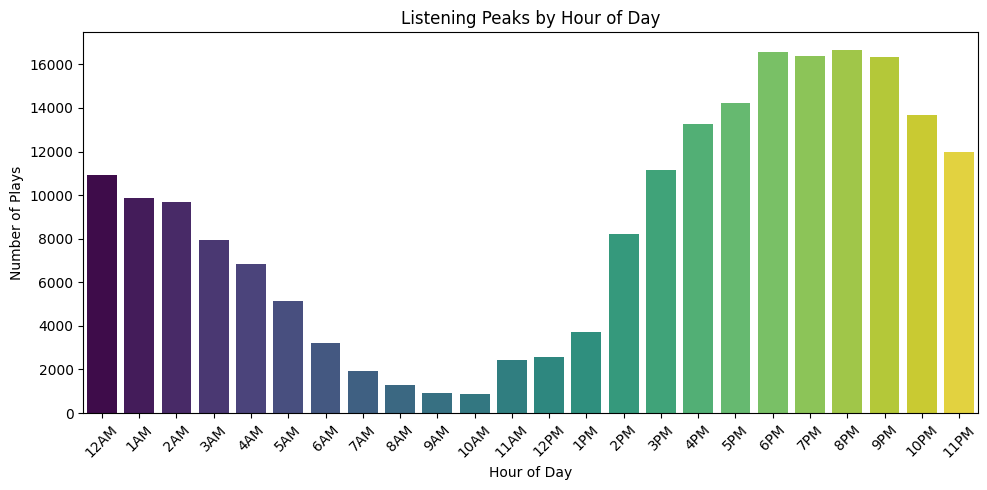

In [223]:
# Listening peaks by hour of day (all users combined)
# Prepare hour labels in AM/PM
hour_labels = [f"{h%12 if h%12 != 0 else 12}{'AM' if h < 12 else 'PM'}" for h in range(24)]

# Listening peaks by hour of day (all users combined)
hourly_counts = history_all.groupby('hour').size().reset_index(name='play_count')

plt.figure(figsize=(10,5))
sns.barplot(
    data=hourly_counts,
    x='hour',
    y='play_count',
    palette='viridis',
    hue='hour',
    dodge=False
)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Plays')
plt.title('Listening Peaks by Hour of Day')
plt.xticks(ticks=range(24), labels=hour_labels, rotation=45)
plt.legend().remove()
plt.tight_layout()
plt.show()

The average listening pattern (by hour) is shown here for all users. Most users will follow this pattern generally (as seen in the subplots in Visual 3). And in general, listening peaks in the evening hours (6-9pm).

#### Visual 2
Listening peaks/patterns by day of week (for all users).

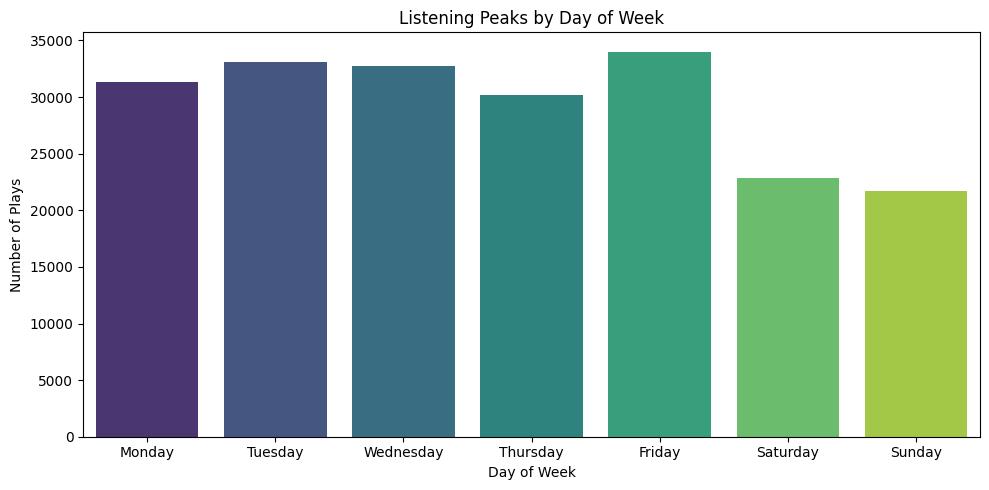

In [226]:
# Listening peaks by day of week
# Listening peaks by day of week
dow_counts = history_all.groupby('day_of_week').size().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).reset_index(name='play_count')

plt.figure(figsize=(10,5))
sns.barplot(data=dow_counts, x='day_of_week', y='play_count', palette='viridis', hue='day_of_week', dodge=False)
plt.xlabel('Day of Week')
plt.ylabel('Number of Plays')
plt.title('Listening Peaks by Day of Week')
plt.tight_layout()
plt.show()

Users tend to listen more during the weekdays (Monday - Friday) compared to the weekend (Saturday - Sunday). This may indicate some behavioral genaralizations - that people are listening to music more during the week because they are passively listening during their commute, while they do work, or while exercising. And during the weekend, people may be listening less, as they are more likely to be doing social activities, requiring more human interaction, without listening to music.

#### Visual 3
Listening peaks/patterns by hour of the day (for each user individually).

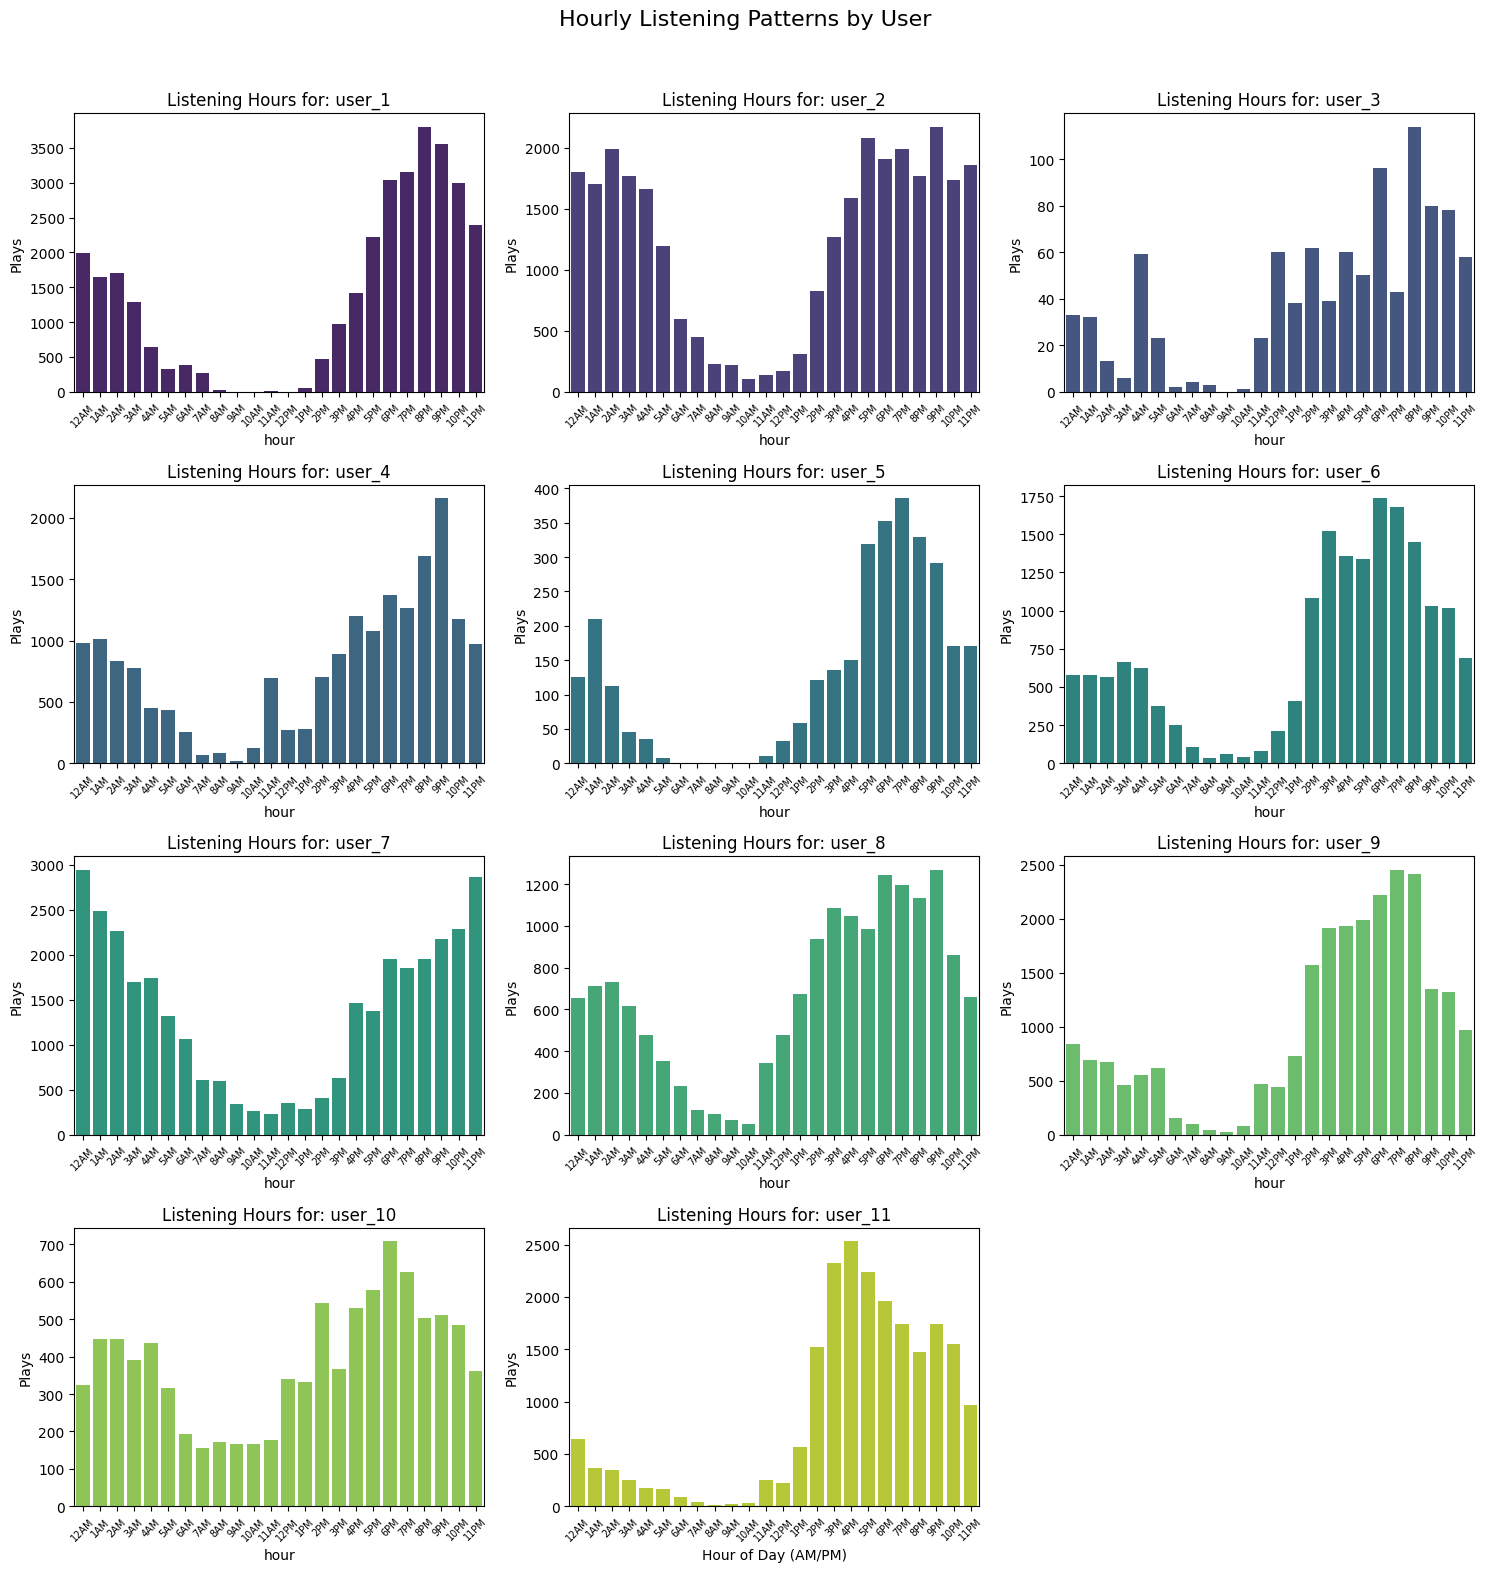

In [237]:
# Listening patterns by hour for each user (subplots)
# Unique users sorted numerically
users = sorted(history_all['user_id'].unique(), key=lambda x: int(x.split('_')[1]))
num_users = len(users)
cols = 3
rows = (num_users + cols - 1) // cols

# Create figure with subplots and x-axis not shared
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4), sharex=False)
axes = axes.flatten()

# Set viridis palette
palette = sns.color_palette("viridis", n_colors=num_users)
user_colors = dict(zip(users, palette))

for i, user in enumerate(users):
    ax = axes[i]
    
    # Filter data for the user
    user_data = history_all[history_all['user_id'] == user]
    
    # Count plays per hour
    hourly_counts = user_data.groupby('hour').size().reindex(range(24), fill_value=0).reset_index()
    hourly_counts.columns = ['hour', 'play_count']
    
    # Plot barplot
    sns.barplot(
        data=hourly_counts,
        x='hour',
        y='play_count',
        color=user_colors[user],
        ax=ax
    )
    
    # Set titles and labels
    ax.set_title(f'Listening Hours for: {user}')
    ax.set_ylabel('Plays')
    
    # AM/PM labels
    ax.set_xticks(range(24))
    ax.set_xticklabels(hour_labels, rotation=45, size=7)

# Remove empty subplots if grid has extra axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Hourly Listening Patterns by User", fontsize=16)
plt.xlabel("Hour of Day (AM/PM)")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

Listening activity is generally lower and decreasing during early morning hours (12-6sm) for most users, with a gradual increase starting around (7-9am). Peaks in listening occur in the afternoon and evening hours (2-9pm), suggesting that these times may be ideal for introducing new content or sending recommendations. Some users (i.e. user_10) show higher activity throughout the day, while others have more concentrated listening patterns. This shows variability in user behavior, which could inform personalized recommendation timing - like recommending "mood" or "time of day" based playlists. Late-night usage (2-3am) remains significant for certain users, suggesting an opportunity to target night-time listeners for specific genres or playlists.

### Curation levels
Curation levels are set based on engagement: not_curated (no engagement outside of streaming), library (low engagement for saving to library - pressing heart button), playlist (moderate engagement of creating playlists and adding to specific playlists), both (high engagement - highest level of curation behavior of saving and adding to playlists).

In [238]:
# Sanity check for curation labels
print("Curation label counts:")
print(history_all["curation_label"].value_counts(dropna=False))

# Set an explicit order for plots/tables later
curation_order = ["not_curated", "library", "playlist", "both"]

history_all["curation_label"] = pd.Categorical(
    history_all["curation_label"],
    categories=curation_order,
    ordered=True
)

print("\nOrdered curation labels:")
print(history_all["curation_label"].cat.categories)

Curation label counts:
curation_label
playlist       83788
not_curated    66015
library        33301
both           22745
Name: count, dtype: int64

Ordered curation labels:
Index(['not_curated', 'library', 'playlist', 'both'], dtype='object')


### Summary tables
Summary tables of engagement by time data (hour of the day).

In [186]:
# Engagement by hour of day and curation label
hour_curation_summary = (
    history_all
    .groupby(["hour_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

display(hour_curation_summary.head(20))

# Share of engagement within each hour

hour_curation_summary["stream_share_within_hour"] = (
    hour_curation_summary["stream_count"] /
    hour_curation_summary.groupby("hour_est")["stream_count"].transform("sum")
)

hour_curation_summary["minutes_share_within_hour"] = (
    hour_curation_summary["total_minutes"] /
    hour_curation_summary.groupby("hour_est")["total_minutes"].transform("sum")
)

display(hour_curation_summary.head(20))

,hour_est,curation_label,stream_count,total_minutes
0,0,not_curated,1944,3141.247400
1,0,library,1034,1929.598817
2,0,playlist,2396,4088.611267
3,0,both,813,1258.916517
4,1,not_curated,1363,2332.590133
5,1,library,718,1303.810617
6,1,playlist,1821,2717.387150
7,1,both,431,860.864833
8,2,not_curated,846,1658.258567
9,2,library,386,767.917150


,hour_est,curation_label,stream_count,total_minutes,stream_share_within_hour,minutes_share_within_hour
0,0,not_curated,1944,3141.247400,0.314207,0.301510
1,0,library,1034,1929.598817,0.167125,0.185211
2,0,playlist,2396,4088.611267,0.387264,0.392442
3,0,both,813,1258.916517,0.131405,0.120836
4,1,not_curated,1363,2332.590133,0.314563,0.323313
5,1,library,718,1303.810617,0.165705,0.180717
6,1,playlist,1821,2717.387150,0.420263,0.376648
7,1,both,431,860.864833,0.099469,0.119322
8,2,not_curated,846,1658.258567,0.308421,0.348082
9,2,library,386,767.917150,0.140722,0.161192


Playlist content is most significant during late night/early hours:
* At 12am, playlists account for 2,396 streams (38.7%) and 4,088.6 minutes (39.2%) of total engagement, making it the most consumed curation type.

This dominance continues through 1am (1,821 streams, 42.0%; 2,717.4 minutes, 37.7%) and 2am (1,313 streams, 47.9%; 1,909.4 minutes, 40.1%).

That being said, not curated tracks are also significant at this time:
* At 12am, not curated tracks account for 1,944 streams (31.4%) and 3,141.2 minutes (30.2%).
* By 4am, the share of minutes for not curated tracks increases to 939.5 minutes (42.6%), showing users may be passively listening during early morning hours.

Perhaps they have their music on and fall asleep to it, meaning once playlists finish, Spotify's recommendation system kicks in, and music is listened to passively (no engagement or curation).

Saved (Library) only content has smaller but stable engagement:
* For 12-4am, library tracks consistently represent 11–17% of streams and 8–19% of minutes, e.g., hour 1 has 718 streams (16.6%) and 1,303.8 minutes (18.1%).

This suggests users selectively consume library content rather than relying on playlists - or again, users may be using their library (saved list) as a playlist itself as they listen very passively.

Tracks appearing in both playlists and library have the lowest share
“Both” tracks consistently have the smallest engagement, approximately less than 10% at any hour

This indicates users may be actively moving items from saved to playlist, and not getting repeated exposure across playlists and libraries.


Engagement patterns across hours:
Playlist streams increase in proportion from 12-3am (38.7% → 48.8%), while not curated streams slightly decrease (31.4% → 28.5%).
Minutes share for not curated content is higher than its stream share from 2-4am, suggesting these tracks are listened to for longer durations per stream.

In [240]:
# Engagement by day of week and curation label

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

history_all["day_of_week_est"] = pd.Categorical(
    history_all["day_of_week_est"],
    categories=day_order,
    ordered=True
)

day_curation_summary = (
    history_all
    .groupby(["day_of_week_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

day_curation_summary["stream_share_within_day"] = (
    day_curation_summary["stream_count"] /
    day_curation_summary.groupby("day_of_week_est")["stream_count"].transform("sum")
)

day_curation_summary["minutes_share_within_day"] = (
    day_curation_summary["total_minutes"] /
    day_curation_summary.groupby("day_of_week_est")["total_minutes"].transform("sum")
)

display(day_curation_summary)

/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_37301/3722777796.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_curation_summary.groupby("day_of_week_est")["stream_count"].transform("sum")
/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_37301/3722777796.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_curation_summary.groupby("day_of_week_est")["total_minutes"].transform("sum")


,day_of_week_est,curation_label,stream_count,total_minutes,stream_share_within_day,minutes_share_within_day
0,Monday,not_curated,10124,17994.515683,0.316286,0.334306
1,Monday,library,5431,9571.085967,0.169671,0.177814
2,Monday,playlist,13029,18672.831683,0.407042,0.346908
3,Monday,both,3425,7588.053183,0.107001,0.140972
4,Tuesday,not_curated,10467,18845.704450,0.324096,0.345917
5,Tuesday,library,4721,8121.124650,0.146179,0.149065
6,Tuesday,playlist,13459,19793.556167,0.416739,0.363315
7,Tuesday,both,3649,7720.044150,0.112986,0.141703
8,Wednesday,not_curated,10460,17993.705050,0.315650,0.328067
9,Wednesday,library,5327,9161.354850,0.160752,0.167033


* Playlists lead streams every day: e.g., Monday 13,029 (40.7%), Wednesday 13,995 (42.2%), Saturday 9,727 (43.0%).
* Not curated tracks are significant for minutes: e.g., Sunday 14,427 min (35.2%), Tuesday 18,846 min (34.6%).
* Library-only engagement is more stable and moderate: ~15–17% of streams, ~15–18% of minutes.
* “Both” tracks are smallest share: ~10–12% of streams, ~13–14% of minutes.
* Weekday vs. weekend: Playlists slightly higher on weekends; not curated minutes share rises on Sunday, suggesting more passive listening.

### User (Individual/Comparison)
1. User-level hourly shares
- For each user and hour: what share of their listening is not_curated, library, playlist, both
2. User-level hourly shares
- For each user and weekday: what share of their listening is not_curated, library, playlist, both

- then average across the users

In [188]:
# User-level hourly engagement summary
user_hour_curation = (
    history_all
    .groupby(["user_id", "hour_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

# Compute within-user-within-hour shares
user_hour_curation["stream_share_user_hour"] = (
    user_hour_curation["stream_count"] /
    user_hour_curation.groupby(["user_id", "hour_est"])["stream_count"].transform("sum")
)

user_hour_curation["minutes_share_user_hour"] = (
    user_hour_curation["total_minutes"] /
    user_hour_curation.groupby(["user_id", "hour_est"])["total_minutes"].transform("sum")
)

print("Shape of user_hour_curation:", user_hour_curation.shape)
display(user_hour_curation.head(20))

Shape of user_hour_curation: (1056, 7)


,user_id,hour_est,curation_label,stream_count,total_minutes,stream_share_user_hour,minutes_share_user_hour
0,user_1,0,not_curated,49,59.483550,0.109620,0.128943
1,user_1,0,library,0,0.000000,0.000000,0.000000
2,user_1,0,playlist,398,401.834833,0.890380,0.871057
3,user_1,0,both,0,0.000000,0.000000,0.000000
4,user_1,1,not_curated,25,41.783267,0.081169,0.154829
5,user_1,1,library,0,0.000000,0.000000,0.000000
6,user_1,1,playlist,283,228.084500,0.918831,0.845171
7,user_1,1,both,0,0.000000,0.000000,0.000000
8,user_1,2,not_curated,70,59.211850,0.194986,0.184362
9,user_1,2,library,0,0.000000,0.000000,0.000000


In [189]:
# Average hourly shares across users

avg_user_hour_curation = (
    user_hour_curation
    .groupby(["hour_est", "curation_label"], observed=False)
    .agg(
        avg_stream_share=("stream_share_user_hour", "mean"),
        avg_minutes_share=("minutes_share_user_hour", "mean"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

display(avg_user_hour_curation.head(20))

,hour_est,curation_label,avg_stream_share,avg_minutes_share,user_count
0,0,not_curated,0.423420,0.365028,11
1,0,library,0.122575,0.168973,11
2,0,playlist,0.320749,0.337698,11
3,0,both,0.133256,0.128301,11
4,1,not_curated,0.436348,0.397785,11
5,1,library,0.121915,0.141915,11
6,1,playlist,0.340403,0.369547,11
7,1,both,0.101334,0.090754,11
8,2,not_curated,0.461291,0.452075,11
9,2,library,0.113248,0.124771,11


In [190]:
# User-level day-of-week engagement summary

user_day_curation = (
    history_all
    .groupby(["user_id", "day_of_week_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

# Compute within-user-within-day shares
user_day_curation["stream_share_user_day"] = (
    user_day_curation["stream_count"] /
    user_day_curation.groupby(["user_id", "day_of_week_est"])["stream_count"].transform("sum")
)

user_day_curation["minutes_share_user_day"] = (
    user_day_curation["total_minutes"] /
    user_day_curation.groupby(["user_id", "day_of_week_est"])["total_minutes"].transform("sum")
)

print("Shape of user_day_curation:", user_day_curation.shape)
display(user_day_curation.head(20))

Shape of user_day_curation: (308, 7)


/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_37301/1617864915.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_day_curation.groupby(["user_id", "day_of_week_est"])["stream_count"].transform("sum")
/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_37301/1617864915.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_day_curation.groupby(["user_id", "day_of_week_est"])["total_minutes"].transform("sum")


,user_id,day_of_week_est,curation_label,stream_count,total_minutes,stream_share_user_day,minutes_share_user_day
0,user_1,Monday,not_curated,693,247.562683,0.123794,0.070518
1,user_1,Monday,library,0,0.000000,0.000000,0.000000
2,user_1,Monday,playlist,4905,3263.064967,0.876206,0.929482
3,user_1,Monday,both,0,0.000000,0.000000,0.000000
4,user_1,Tuesday,not_curated,677,240.559433,0.134459,0.074252
5,user_1,Tuesday,library,0,0.000000,0.000000,0.000000
6,user_1,Tuesday,playlist,4358,2999.211667,0.865541,0.925748
7,user_1,Tuesday,both,0,0.000000,0.000000,0.000000
8,user_1,Wednesday,not_curated,723,199.377100,0.142155,0.062870
9,user_1,Wednesday,library,0,0.000000,0.000000,0.000000


In [191]:
# Average day-of-week shares across users

avg_user_day_curation = (
    user_day_curation
    .groupby(["day_of_week_est", "curation_label"], observed=False)
    .agg(
        avg_stream_share=("stream_share_user_day", "mean"),
        avg_minutes_share=("minutes_share_user_day", "mean"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

display(avg_user_day_curation.head(20))

,day_of_week_est,curation_label,avg_stream_share,avg_minutes_share,user_count
0,Monday,not_curated,0.381623,0.350764,11
1,Monday,library,0.134477,0.147000,11
2,Monday,playlist,0.370347,0.385020,11
3,Monday,both,0.113553,0.117217,11
4,Tuesday,not_curated,0.360011,0.322688,11
5,Tuesday,library,0.138518,0.143654,11
6,Tuesday,playlist,0.388049,0.408329,11
7,Tuesday,both,0.113422,0.125329,11
8,Wednesday,not_curated,0.358519,0.334362,11
9,Wednesday,library,0.134522,0.140132,11


### Visualizations (Q1)
1. Visual 1: Hourly average stream share by curation label
2. Visual 2: Hourly average minutes share by curation label
3. Visual 3: Day-of-week average stream share by curation label
4. Visual 4: Day-of-week average minutes share by curation label

#### Visual 1
Hourly average stream share by curation label

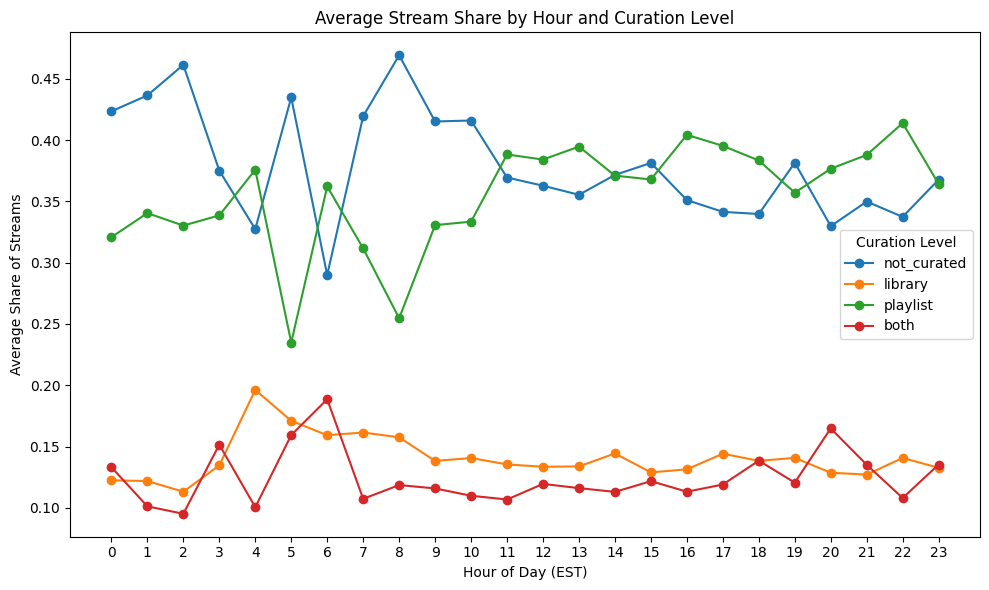

In [192]:
# Visual 1: Hourly average stream share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_hour_curation[avg_user_hour_curation["curation_label"] == label]
    plt.plot(temp["hour_est"], temp["avg_stream_share"], marker="o", label=label)

plt.title("Average Stream Share by Hour and Curation Level")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average Share of Streams")
plt.xticks(range(0, 24))
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 2
Hourly average minutes share by curation label

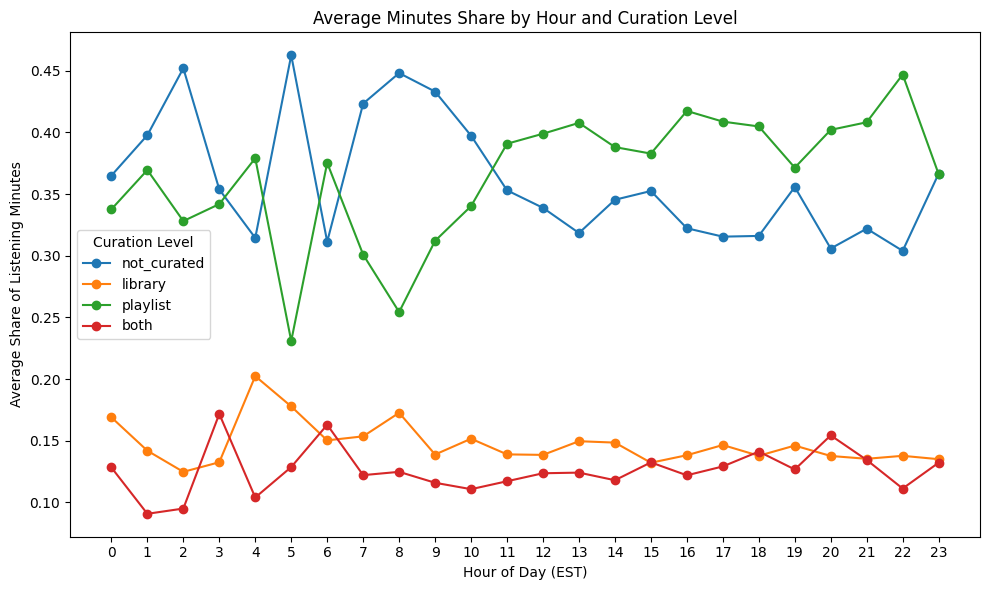

In [193]:
# Visual 2:Hourly average minutes share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_hour_curation[avg_user_hour_curation["curation_label"] == label]
    plt.plot(temp["hour_est"], temp["avg_minutes_share"], marker="o", label=label)

plt.title("Average Minutes Share by Hour and Curation Level")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average Share of Listening Minutes")
plt.xticks(range(0, 24))
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 3
Day-of-week average stream share by curation label 

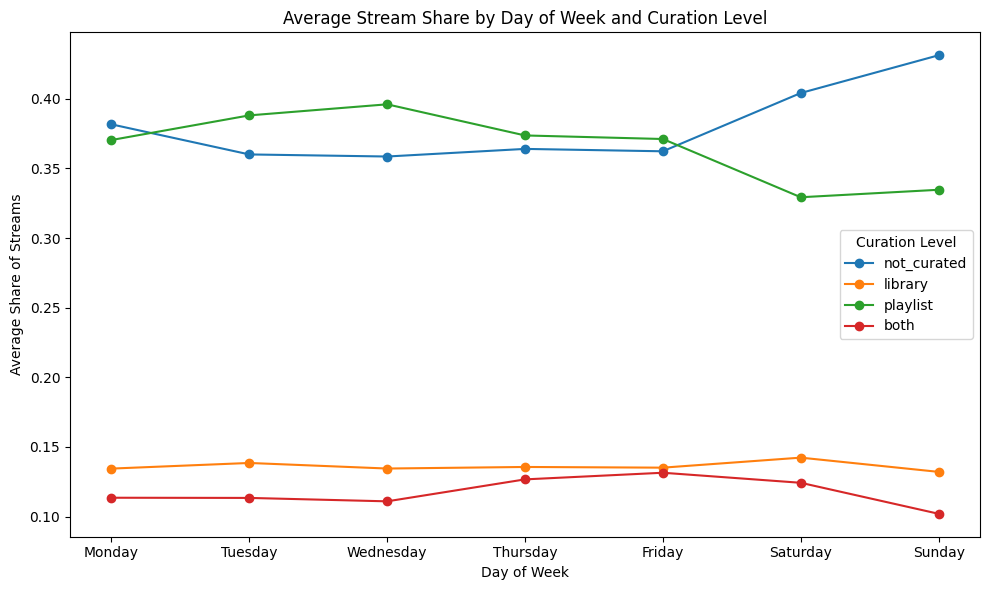

In [194]:
# Visual 3: Day-of-week average stream share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_day_curation[avg_user_day_curation["curation_label"] == label]
    plt.plot(temp["day_of_week_est"], temp["avg_stream_share"], marker="o", label=label)

plt.title("Average Stream Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Streams")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 4
Day-of-week average minutes share by curation label

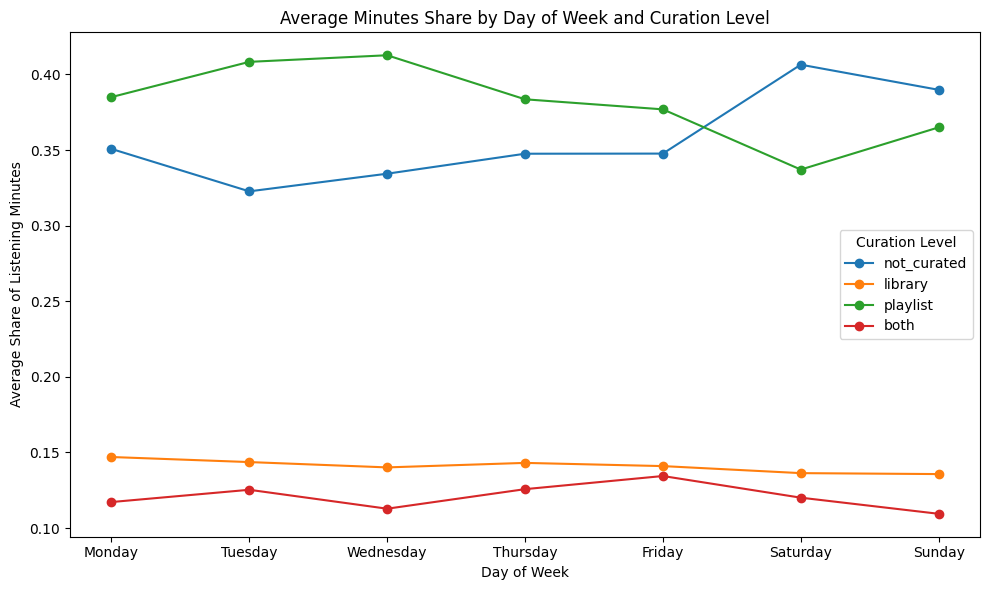

In [195]:
# Visual 4: Day-of-week average minutes share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_day_curation[avg_user_day_curation["curation_label"] == label]
    plt.plot(temp["day_of_week_est"], temp["avg_minutes_share"], marker="o", label=label)

plt.title("Average Minutes Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Listening Minutes")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

### Optional Visuals
Bar chart(instead of line)

#### Visual 3.2
Stream share grouped bars 

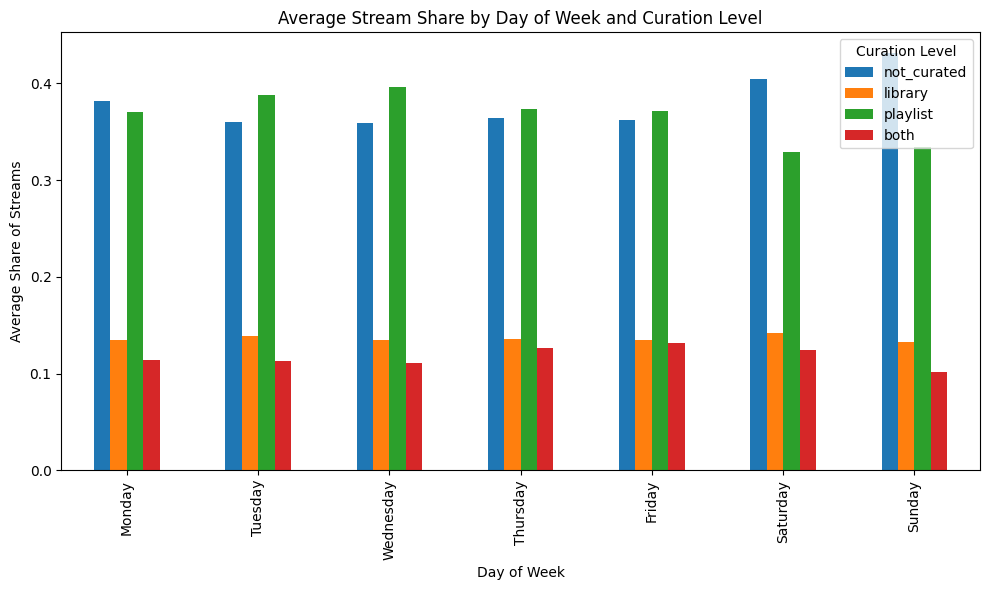

In [196]:
weekday_stream_pivot = avg_user_day_curation.pivot(
    index="day_of_week_est",
    columns="curation_label",
    values="avg_stream_share"
)

weekday_stream_pivot = weekday_stream_pivot[curation_order]

weekday_stream_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Average Stream Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Streams")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 4.2
Minutes share grouped bars

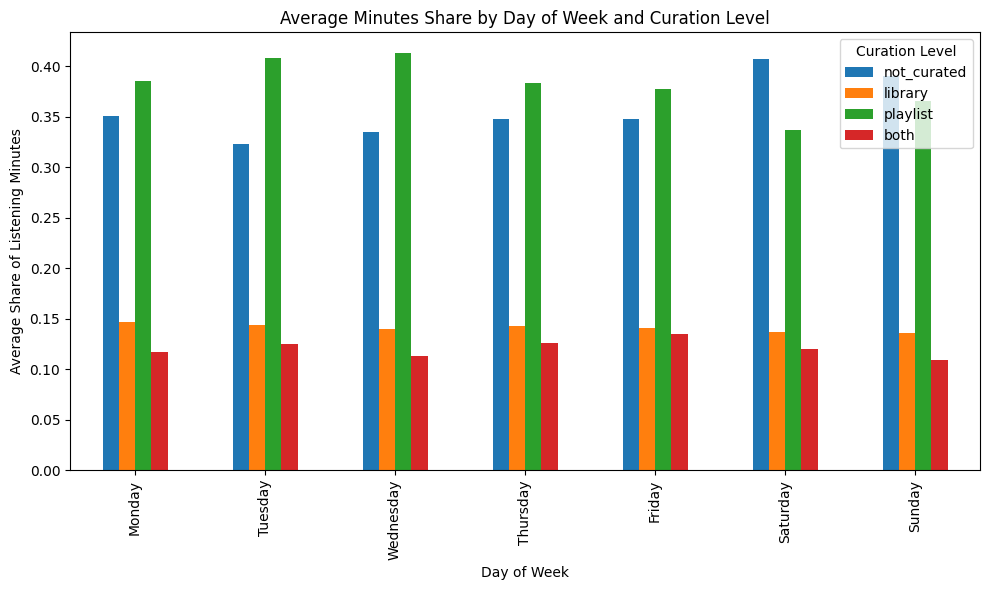

In [197]:
weekday_minutes_pivot = avg_user_day_curation.pivot(
    index="day_of_week_est",
    columns="curation_label",
    values="avg_minutes_share"
)

weekday_minutes_pivot = weekday_minutes_pivot[curation_order]

weekday_minutes_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Average Minutes Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Listening Minutes")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

### Q1 Insights
1. **Time of day** appears to be a **stronger** behavioral signal than day of week for curated vs non-curated listening.
- The hourly charts show much more movement than the weekday charts
2. Not-curated content is stronger in the late night / early morning
- From roughly 12 AM to about 10 AM, not_curated is often the largest share, especially in both: average stream share & average minutes share
3. Playlist-curated content becomes stronger later in the day
- From around 11 AM onward, playlist generally rises and often overtakes not_curated, especially through the afternoon and evening.
- **playlist-curated** content --> **later** in the day (after 11 am, afternoon)
- **not-curated** content --> more dominant **earlier** in the day (00:00-10:00)
4. Library is relatively stable and secondary
- library stays fairly flat across both hour and weekday charts, usually around a smaller middle share. It matters, but it does not appear to drive the main behavioral shifts.
5. **Day-of-week differences are present but smaller; playlist-curated listening is somewhat stronger on weekdays, while not-curated listening is relatively more prominent on weekends.**
- Not curated > Playlist only on weekends (why? What caused the shift, what user behavior)
    - weekend: not curated > playlist
    - weekday: playlist > not curated
- -->
    - **weekday** listening may be a bit more **playlist-structured**
    - **weekend** listening may be a bit more **spontaneous or less intentionally** curated

## Research Question 2
Which tracks are heavily consumed but not curated, and what does this reveal about missed recommendation opportunities?

### Noncurated Track Stats

In [198]:
# Aggregate track-level stats from pre-merged dataset
track_stats = (
    history_all.groupby(["match_key", "track_clean", "artist_clean"])
    .agg(
        total_plays=("track_clean", "count"),  
        total_minutes=("minutes_played", "sum"),
        num_users=("user_id", "nunique"),
        max_curation=("curation_level", "max")
    )
    .reset_index()
)

# Remove "Unknown Track" / "Unknown Artist"
track_stats = track_stats[
    (~track_stats["track_clean"].str.lower().eq("unknown track")) &
    (~track_stats["artist_clean"].str.lower().eq("unknown artist"))
].copy()

# Filter to tracks that are NOT curated
not_curated_tracks = track_stats[track_stats["max_curation"] == 0]

# Top 20 by total minutes played
top_not_curated_minutes = not_curated_tracks.sort_values("total_minutes", ascending=False).head(20)
display(top_not_curated_minutes[["track_clean", "artist_clean", "total_minutes", "total_plays", "num_users"]])

# Top 20 by total plays
top_not_curated_playcount = not_curated_tracks.sort_values("total_plays", ascending=False).head(20)
display(top_not_curated_playcount[["track_clean", "artist_clean", "total_plays", "total_minutes", "num_users"]])

,track_clean,artist_clean,total_minutes,total_plays,num_users
1420,yennai maatrum kadhale from naanum rowdy dhaan,anirudh ravichander,238.932617,60,1
19292,your idol,saja boys,182.208683,73,3
24477,white noise 3 hour long,white noise therapy,180.469833,2,1
15876,run to the sun,nerd,159.198833,42,1
2450,a million miles away from belle soundtrack en...,belle,149.760800,21,1
19104,free,rumi,135.083867,59,2
4965,for good,cynthia erivo,133.445567,31,1
4963,defying gravity,cynthia erivo,132.304617,23,1
1050,ordinary,alex warren,131.921983,49,2
11438,folded,kehlani,127.776133,38,3


,track_clean,artist_clean,total_plays,total_minutes,num_users
23453,1400 999 freestyle feat juice wrld,trippie redd,125,113.652167,3
19292,your idol,saja boys,73,182.208683,3
9210,how its done,huntrx,63,119.979267,3
1420,yennai maatrum kadhale from naanum rowdy dhaan,anirudh ravichander,60,238.932617,1
19104,free,rumi,59,135.083867,2
9520,lemonade feat nav,internet money,56,11.521800,3
9211,takedown,huntrx,55,63.222617,2
1050,ordinary,alex warren,49,131.921983,2
21211,exes,tate mcrae,48,83.919717,3
9321,gone girl feat trippie redd,iann dior,47,16.048750,2


The first table shows the top 20 tracks that were heavily played but not actively curated (i.e., not added to playlists or libraries) based on total minutes listened, while the second table shows based on total number of plays.

The tracks were filtered to remove unknown tracks and artists, so any plays with missing track/artist names are not included in this top 20.
The missing tracks could originate from incomplete user metadata, streaming service anonymization, or missing library/playlist information.

The table showing based on total play count, shows that some tracks are highly consumed by a small number of users (i.e. yennai maatrum kadhale from naanum rowdy dhaan or run to the sun - both were consumed only by 1 user) while others have moderate plays across multiple users. This data suggests potential opportunities for recommendations or playlist promotion.

#### Visual 5

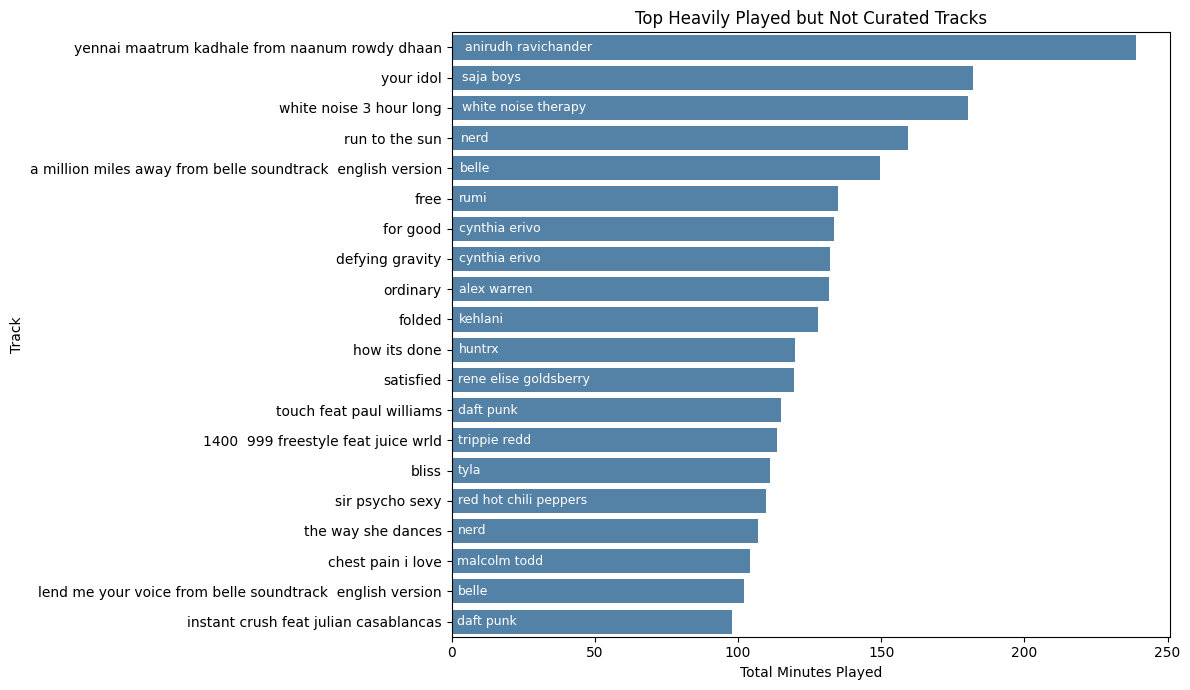

In [207]:
# Filter out "Unknown" tracks before plotting
plot_data = top_not_curated_minutes[
    (top_not_curated_minutes["track_clean"] != "unknown track") &
    (top_not_curated_minutes["artist_clean"] != "unknown artist")
].copy()

# Create display columns
plot_data["track_display"] = plot_data["track_clean"]
plot_data["artist_display"] = plot_data["artist_clean"]
# Reset index for alignment
plot_data = plot_data.reset_index(drop=True)

# Bar chart
plt.figure(figsize=(12, 7))

# Reset index so text aligns with bars
plot_data = plot_data.reset_index(drop=True)

ax = sns.barplot(
    data=plot_data,
    y="track_display",
    x="total_minutes",
    color="steelblue"
)

plt.xlabel("Total Minutes Played")
plt.ylabel("Track")
plt.title("Top Heavily Played but Not Curated Tracks")

# Add artist names inside bars
for i, row in plot_data.iterrows():
    ax.text(
        row["total_minutes"] * 0.02,   # slightly more padding for readability
        i,
        row["artist_display"],
        va='center',
        ha='left',
        color='white',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Opporunity Score (Track)

In [199]:
track_stats["opportunity_score"] = (
    track_stats["total_plays"] * track_stats["num_users"]
)

# Only not curated
not_curated_tracks = track_stats[track_stats["max_curation"] == 0]

top_opportunities = not_curated_tracks.sort_values(
    "opportunity_score", ascending=False
).head(20)

display(top_opportunities[[
    "track_clean", "artist_clean", "total_plays", "num_users", "opportunity_score"
]])

,track_clean,artist_clean,total_plays,num_users,opportunity_score
23453,1400 999 freestyle feat juice wrld,trippie redd,125,3,375
18411,love me not feat rex orange county,ravyn lenae,38,6,228
5921,cake by the ocean,dnce,45,5,225
19292,your idol,saja boys,73,3,219
21129,dracula,tame impala,41,5,205
4535,juna,clairo,34,6,204
17422,illegal,pinkpantheress,40,5,200
9210,how its done,huntrx,63,3,189
21388,opalite,taylor swift,37,5,185
2501,mystical magical,benson boone,44,4,176


An opportunity score was calculated = (total_plays * num_users) to identify tracks that are highly consumed but under-curated. This formulation/calculated field is something that could be applied to a much larger aggregated database of users to see which songs may be prioritized for recommendation systems. On the other hand, tracks with many plays but fewer users could indicate "niche popularity"; tracks with moderate plays across many users indicate "general popularity". This data could allow for recommendation systems to push certain tracks depending on the type of listener the user is.

### User Segmentation
Based on curation behavior.

In [200]:
# Aggregate number of curated vs. not curated tracks per user
user_curation_stats = history_all.groupby("user_id").agg(
    total_tracks=("curation_level", "count"),
    curated_tracks=("curation_level", lambda x: (x > 0).sum()),
    total_minutes=("minutes_played", "sum")
).reset_index()

user_curation_stats["curation_fraction"] = user_curation_stats["curated_tracks"] / user_curation_stats["total_tracks"]

def curation_segment(frac):
    if frac == 0:
        return 0  # no curation
    elif frac <= 0.25:
        return 1  # low curation
    elif frac <= 0.75:
        return 2  # moderate curation
    else:
        return 3  # high curation

user_curation_stats["curation_segment"] = user_curation_stats["curation_fraction"].apply(curation_segment)

segment_summary = (
    user_curation_stats.groupby("curation_segment")
    .agg(
        num_users=("user_id", "count"),
        avg_total_minutes=("total_minutes", "mean"),
        avg_total_tracks=("total_tracks", "mean")
    )
    .reset_index()
)

display(segment_summary)

,curation_segment,num_users,avg_total_minutes,avg_total_tracks
0,1,1,27334.337583,9275.000000
1,2,7,30564.617743,16434.285714
2,3,3,36024.214567,27178.000000


#### Visual 6

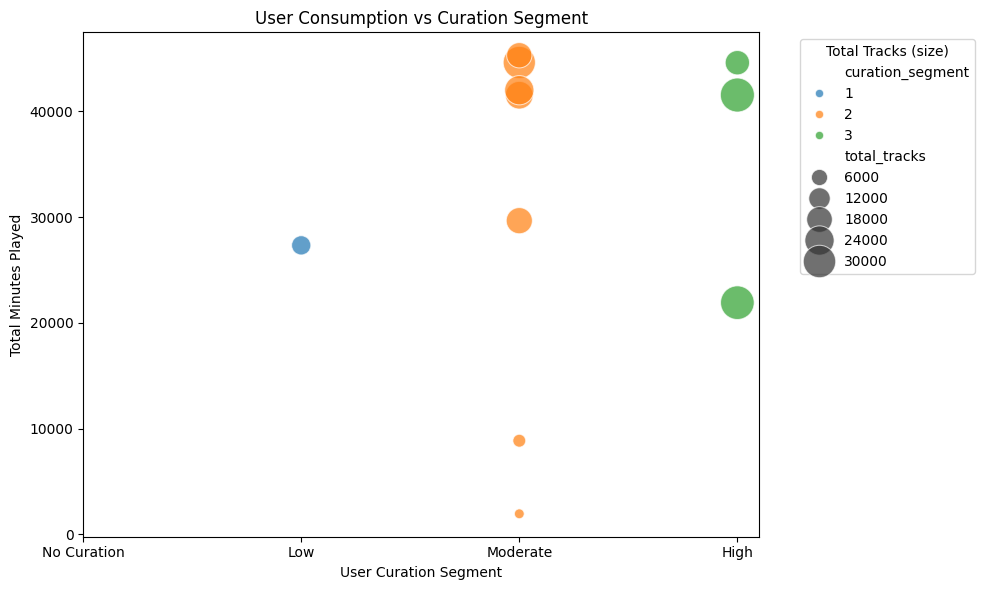

,Curation Segment,Number of Users,Avg Total Minutes,Avg Total Tracks
0,Low,1,27334.337583,9275.000000
1,Moderate,7,30564.617743,16434.285714
2,High,3,36024.214567,27178.000000


In [206]:
# Scatter plot: total minutes vs curation segment
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=user_curation_stats,
    x="curation_segment",
    y="total_minutes",
    size="total_tracks",        # size by total tracks listened
    hue="curation_segment",     # color by segment (curation level)
    palette="tab10",
    sizes=(50, 600),
    alpha=0.7
)

plt.xticks([0, 1, 2, 3], ["No Curation", "Low", "Moderate", "High"])
plt.xlabel("User Curation Segment")
plt.ylabel("Total Minutes Played")
plt.title("User Consumption vs Curation Segment")
plt.legend(title="Total Tracks (size)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

summary_table = (
    user_curation_stats
    .groupby("curation_segment")
    .agg(
        num_users=("user_id", "nunique"),
        avg_total_minutes=("total_minutes", "mean"),
        avg_total_tracks=("total_tracks", "mean")
    )
    .reset_index()
)

# Map segment numbers to labels
summary_table["Curation Segment"] = summary_table["curation_segment"].map({
    0: "No Curation",
    1: "Low",
    2: "Moderate",
    3: "High"
})

# Rearrange columns
summary_table = summary_table[[
    "Curation Segment", "num_users", "avg_total_minutes", "avg_total_tracks"
]]

# Rename for readability
summary_table = summary_table.rename(columns={
    "num_users": "Number of Users",
    "avg_total_minutes": "Avg Total Minutes",
    "avg_total_tracks": "Avg Total Tracks"
})

display(summary_table)

Users with higher curation levels tend to have higher total minutes and more tracks consumed, indicating a strong engagement pattern. While users with low or no curation may be passive listeners, suggesting opportunities for engagement campaigns or playlist suggestions that are pushed in new ways.

## Research Question 3
How does the diversity of curated content compare to actual listening behavior across users?

### EDA

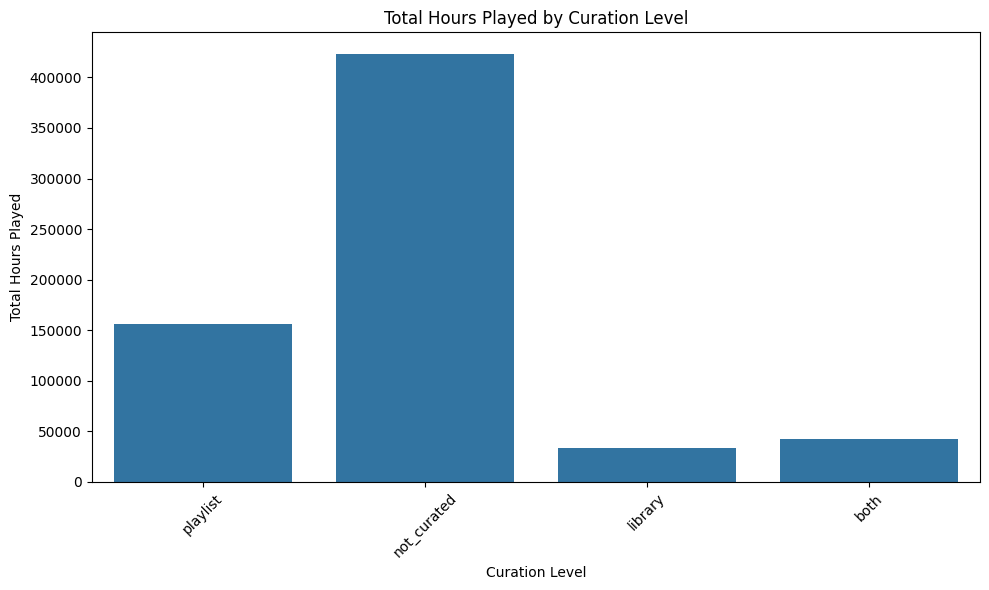

In [124]:
# Analyze total minutes played by curation level with barchart
plt.figure(figsize=(10, 6))
sns.barplot(
    x="curation_label", 
    y="hour", 
    data=full_data, 
    estimator=np.sum, 
    errorbar=None  # replaces ci=None
)
plt.title("Total Hours Played by Curation Level")
plt.xlabel("Curation Level")
plt.ylabel("Total Hours Played")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

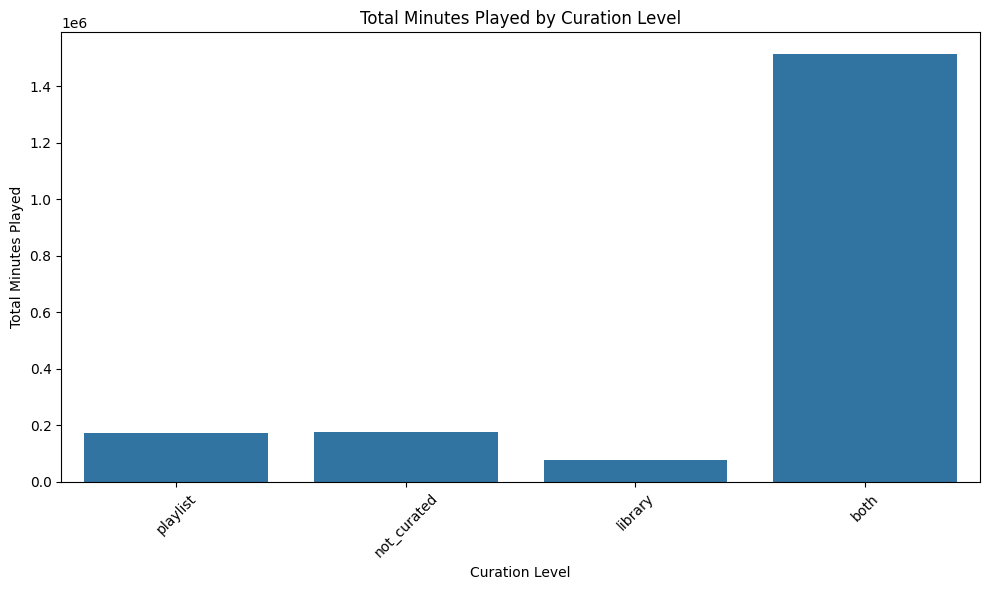

In [125]:
# Analyze total minutes played by curation level with barchart
plt.figure(figsize=(10, 6))
sns.barplot(
    x="curation_label",
    y="minutes_played",
    data=full_data,
    estimator=np.sum,
    errorbar=None  # replaces ci=None
)
plt.title("Total Minutes Played by Curation Level")
plt.xlabel("Curation Level")
plt.ylabel("Total Minutes Played")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analyzing Feature Diversity by Curation Level

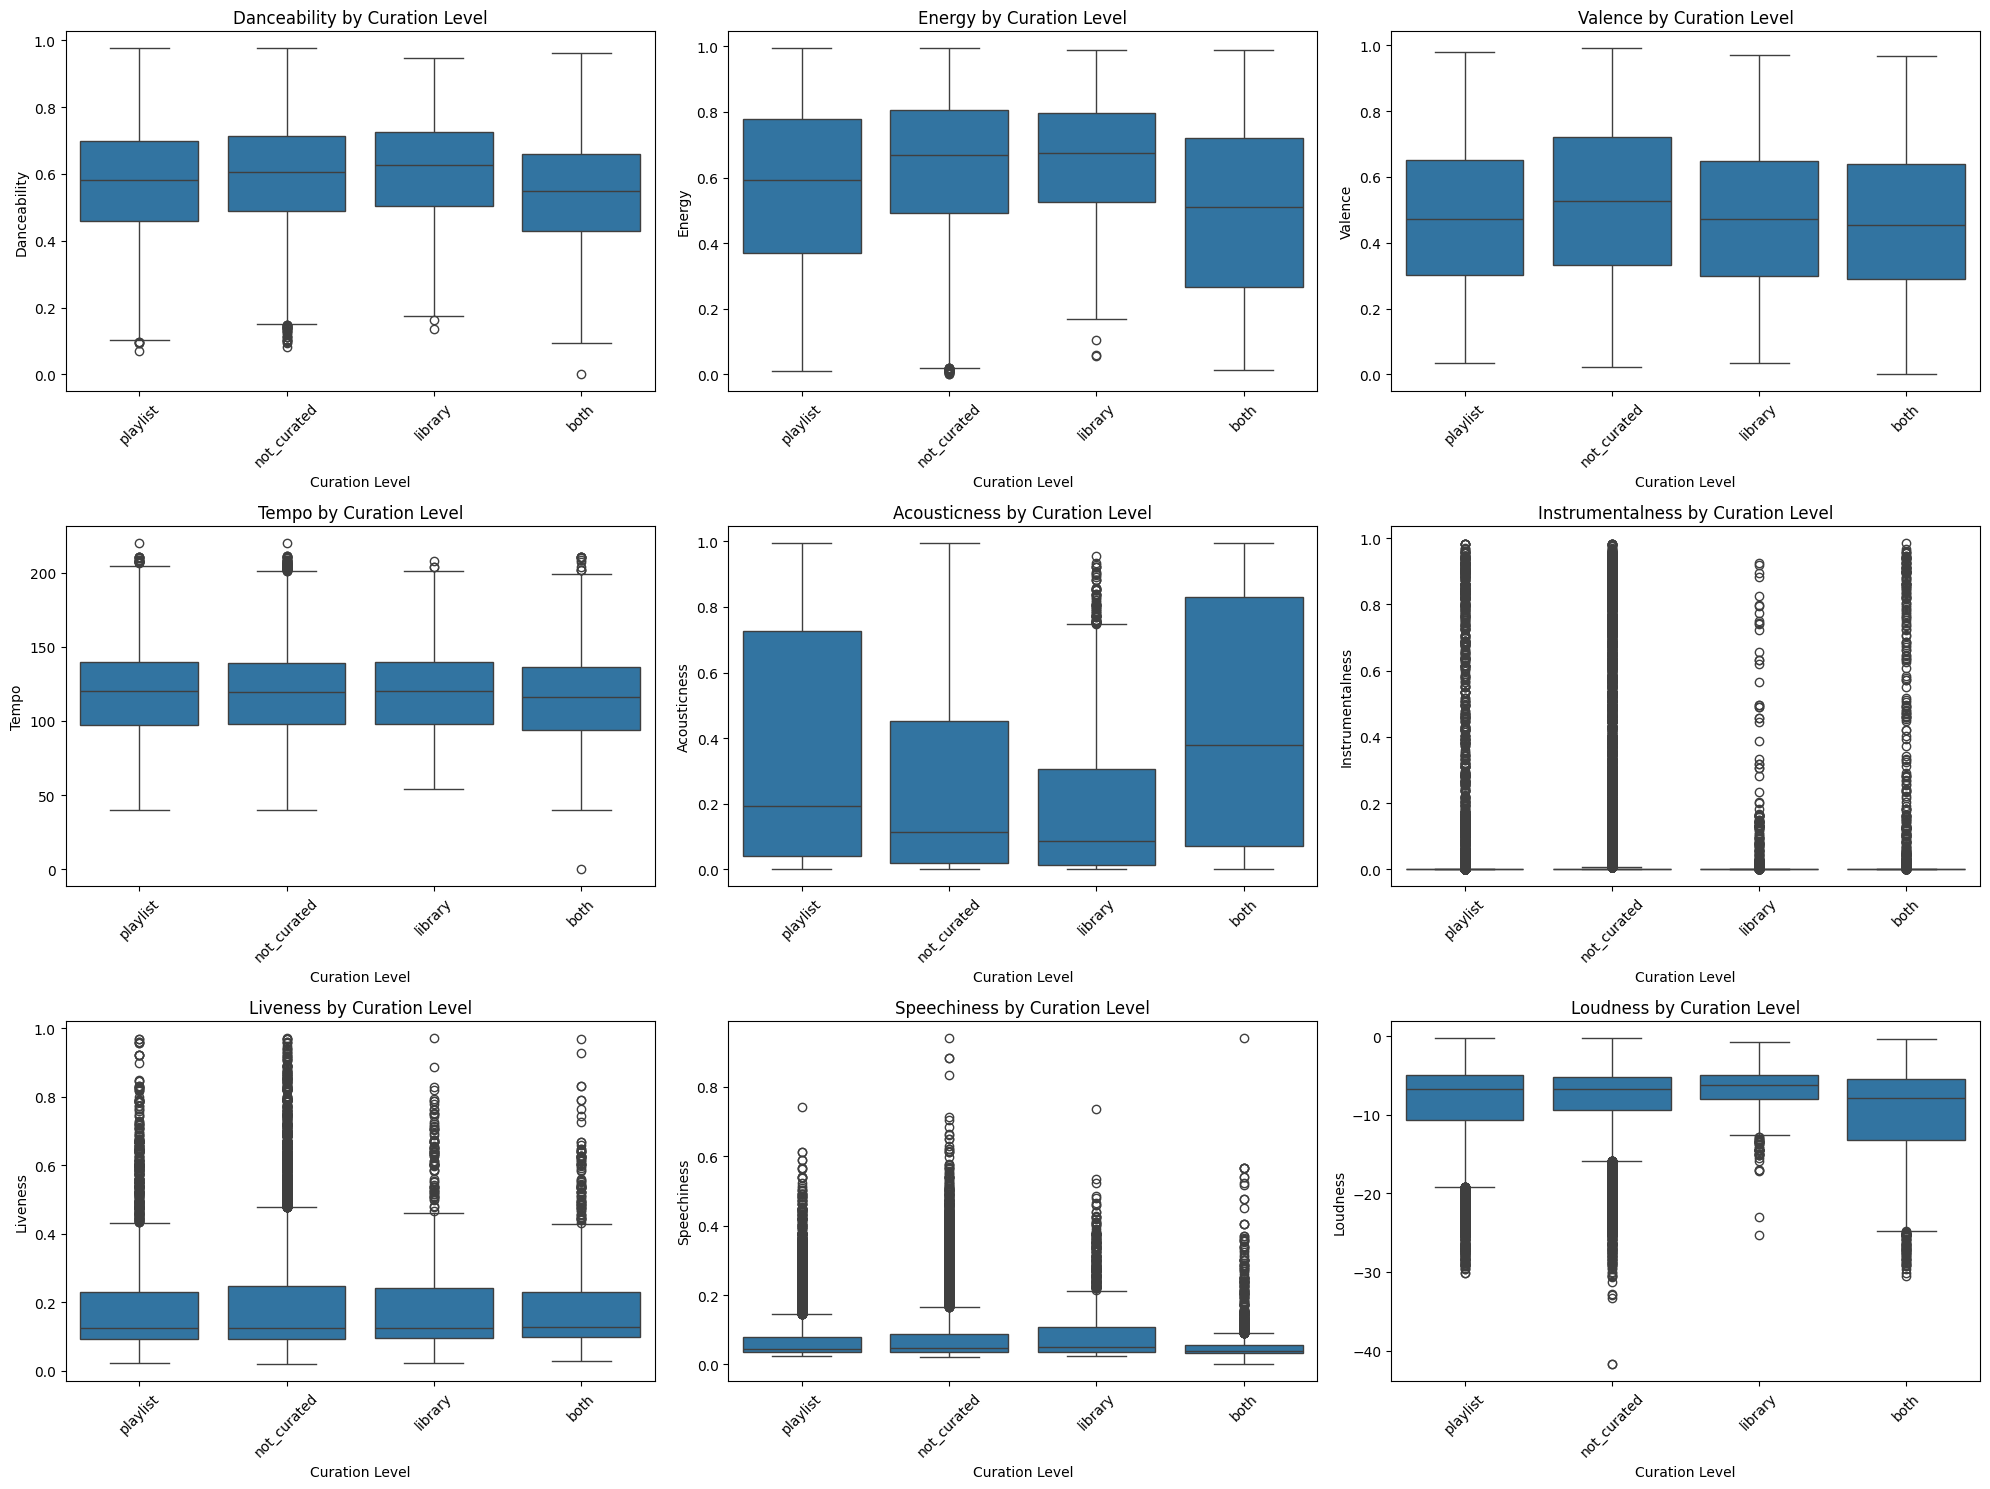

In [126]:
# Create subplots for audio features by curation level
features = ["danceability", "energy", "valence", "tempo", "acousticness", "instrumentalness", "liveness", "speechiness", "loudness"]
plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x="curation_label", y=feature, data=full_data)
    plt.title(f"{feature.capitalize()} by Curation Level")
    plt.xlabel("Curation Level")
    plt.ylabel(feature.capitalize())
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The main audio features that show major differences between curation level are the
* energy
* loudness
* acousticness

These features are perhaps the determining factors for users as to whether they add them to a playlist or library. Other audio features show similar distributions and means, highlighting how these song features are not a major factor in terms of whether a song is placed in one of these curation levels. A caveat would be that certain audio features have more records compared to others.

### Acousticness Analysis

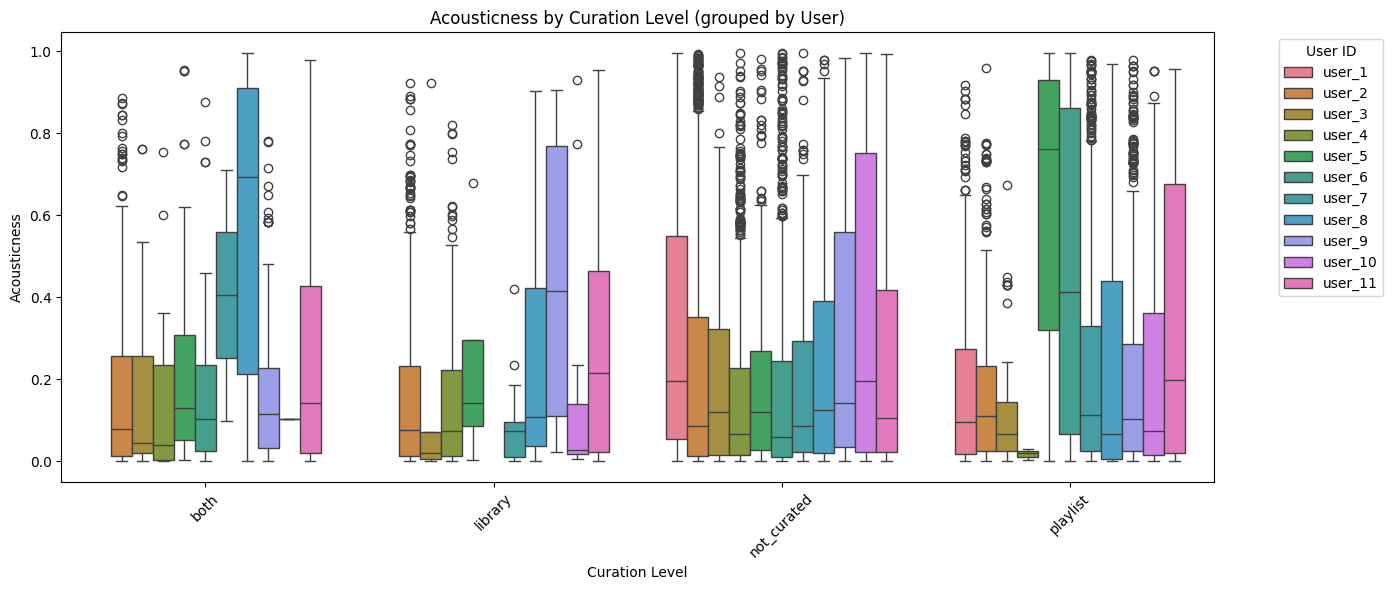

In [127]:
# Acousticness by curation level, grouped by user
plt.figure(figsize=(14, 6))
sns.boxplot(
    x="curation_label", y="acousticness", hue="user_id",
    data=full_data,
    order=sorted(full_data['curation_label'].unique()),
    hue_order=sorted(full_data['user_id'].unique(), key=lambda x: int(x.split('_')[1]))
)
plt.title("Acousticness by Curation Level (grouped by User)")
plt.xlabel("Curation Level")
plt.ylabel("Acousticness")
plt.xticks(rotation=45)
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

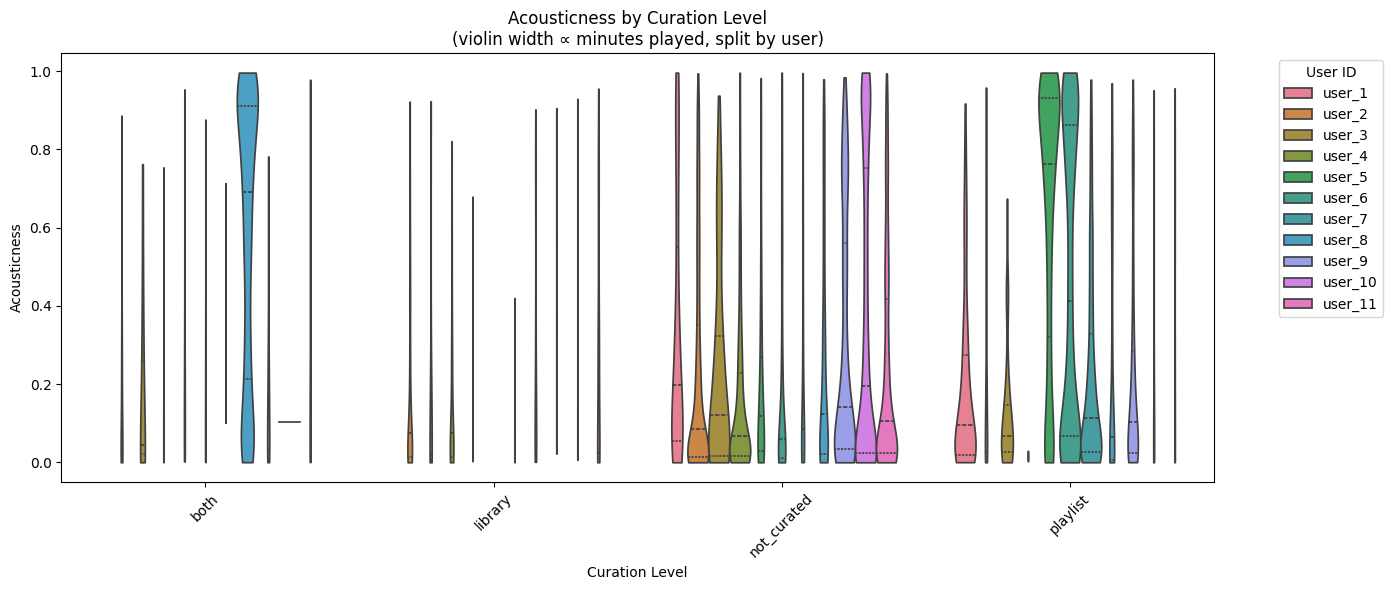

In [128]:
# Violinplots
plt.figure(figsize=(14, 6))

sns.violinplot(
    x="curation_label",
    y="acousticness",
    hue="user_id",
    data=full_data,
    density_norm="count",  # replaces scale="count"
    inner="quartile",
    order=sorted(full_data['curation_label'].unique()),
    hue_order=sorted(full_data['user_id'].unique(), key=lambda x: int(x.split('_')[1])),
    cut=0
)

plt.title("Acousticness by Curation Level\n(violin width ∝ minutes played, split by user)")
plt.xlabel("Curation Level")
plt.ylabel("Acousticness")
plt.xticks(rotation=45)
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Songs with Acoustic levels within the IQR of the acousticness of their listening history are more likely to be placed in their library and even more so for both their library and playlist. Songs that possibly outside of this range could be added to this playlist, but are more likely to be non-curated songs and forgotten about. Users prefer strongly songs that are electronic (software, synthesizers, drum machines, electric guitars and violins) rather than acoustic (acoustic guitars, pianos, or other non-electronic instruments).

### Energy Analysis

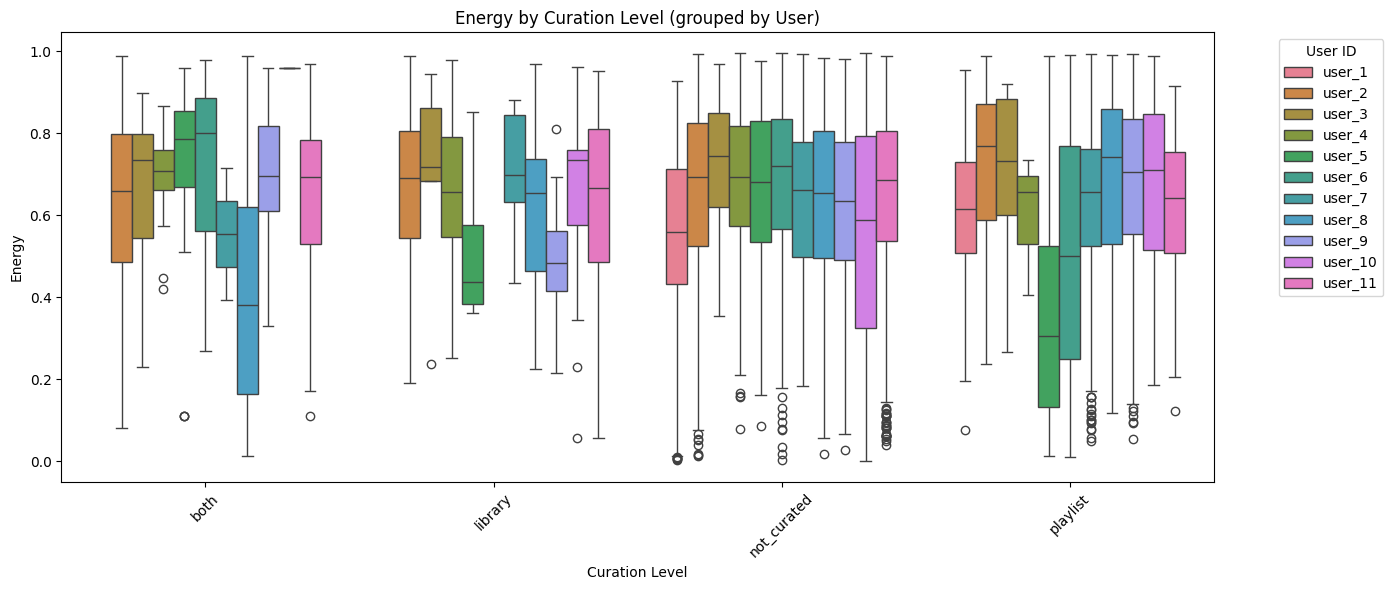

In [129]:
# Energy by curation level by user
plt.figure(figsize=(14, 6))
sns.boxplot(
    x="curation_label", y="energy", hue="user_id",
    data=full_data,
    order=sorted(full_data['curation_label'].unique()),
    hue_order=sorted(full_data['user_id'].unique(), key=lambda x: int(x.split('_')[1]))
)
plt.title("Energy by Curation Level (grouped by User)")
plt.xlabel("Curation Level")
plt.ylabel("Energy")
plt.xticks(rotation=45)
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

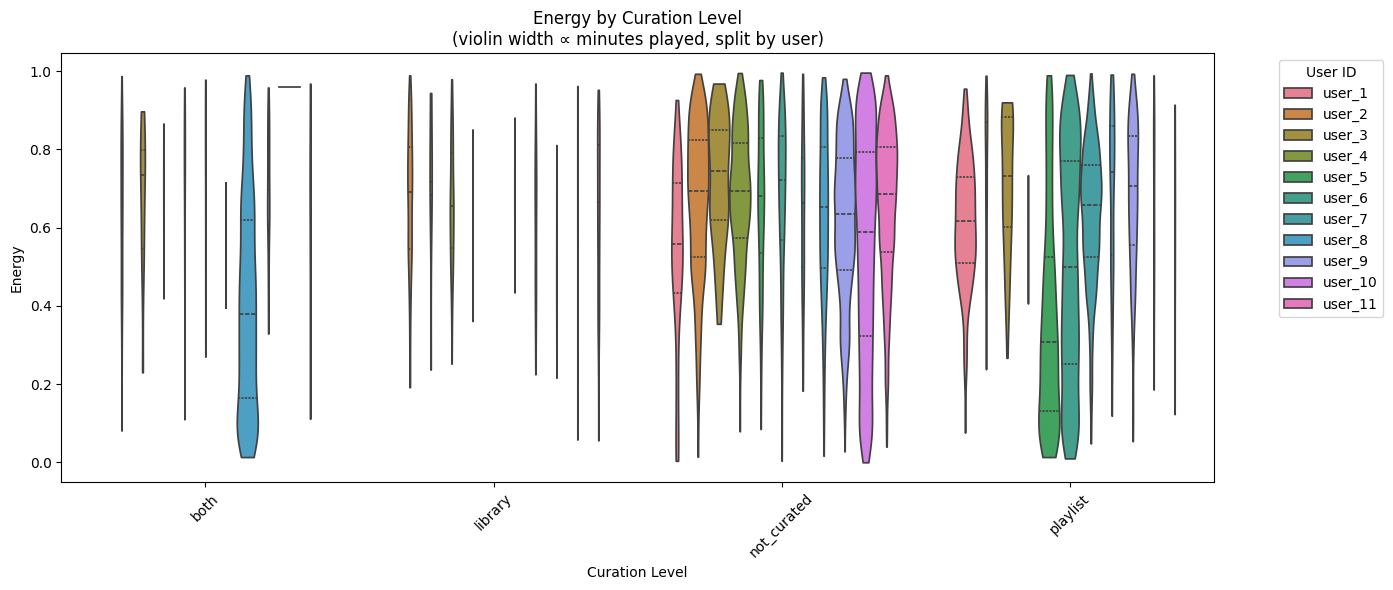

In [130]:
# Violinplot
plt.figure(figsize=(14, 6))

sns.violinplot(
    x="curation_label",
    y="energy",
    hue="user_id",
    data=full_data,
    density_norm="count",  # replaces scale="count"
    inner="quartile",      
    order=sorted(full_data['curation_label'].unique()),
    hue_order=sorted(full_data['user_id'].unique(), key=lambda x: int(x.split('_')[1])),
    cut=0                  
)

plt.title("Energy by Curation Level\n(violin width ∝ minutes played, split by user)")
plt.xlabel("Curation Level")
plt.ylabel("Energy")
plt.xticks(rotation=45)
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Follows similar pattern in terms of saving similar energy levels in songs to playlists or libraries like acousticness. Users tend to save a songs to playlists with a greater range of energy levels while their libraries highlight their true preference. Songs saved to both places have a very succinct level of energy preferences in their songs. Users true preference for energy in songs is varied, but mainly songs that are have higher energy than avg is preferred.

### Loudness Analysis

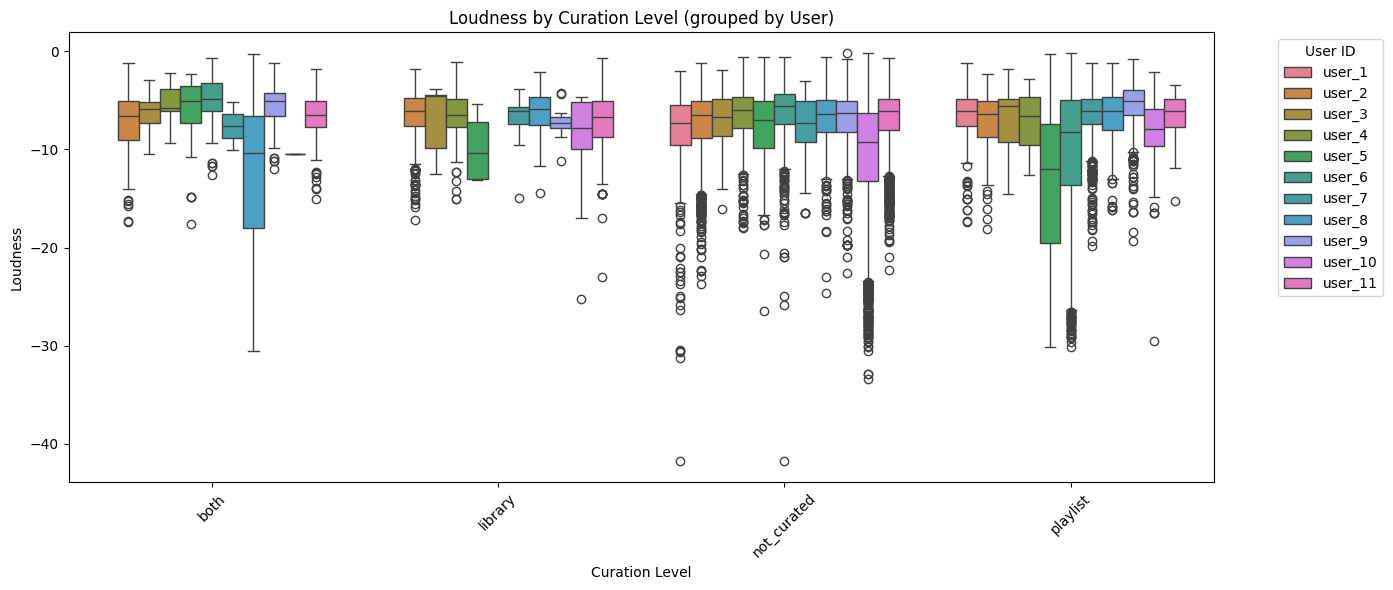

In [131]:
# Loudness by curation level by user
plt.figure(figsize=(14, 6))
sns.boxplot(
    x="curation_label", y="loudness", hue="user_id",
    data=full_data,
    order=sorted(full_data['curation_label'].unique()),
    hue_order=sorted(full_data['user_id'].unique(), key=lambda x: int(x.split('_')[1]))
)
plt.title("Loudness by Curation Level (grouped by User)")
plt.xlabel("Curation Level")
plt.ylabel("Loudness")
plt.xticks(rotation=45)
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

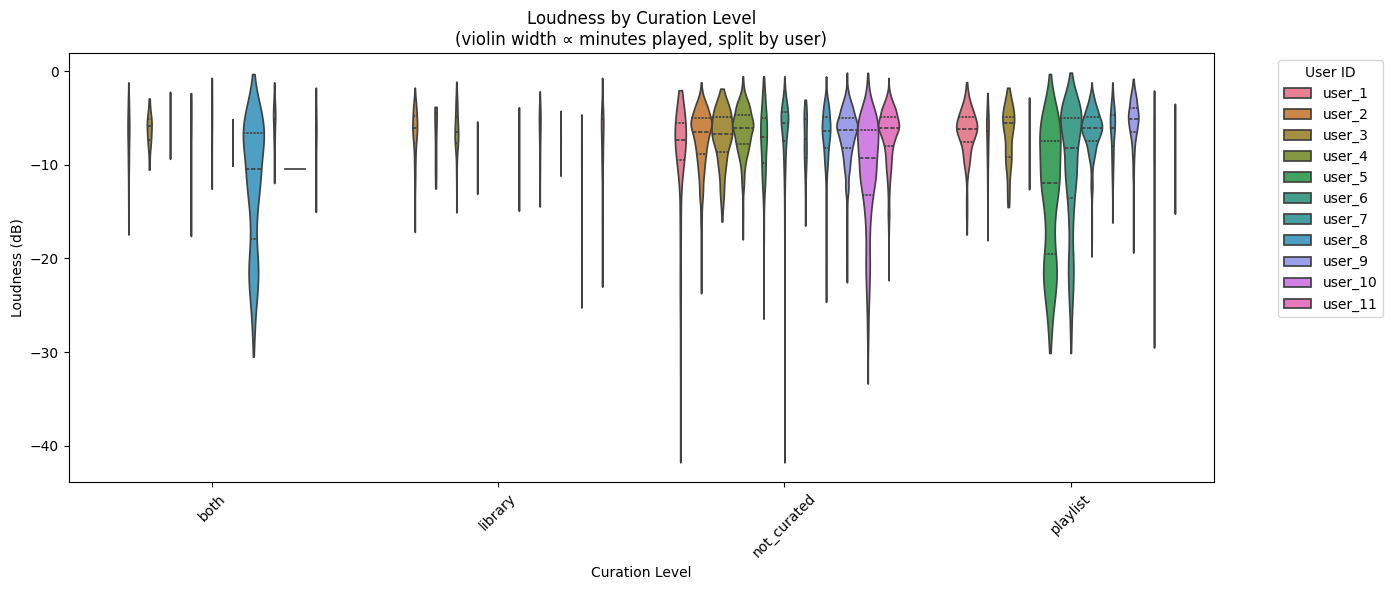

In [132]:
# Violin plot
plt.figure(figsize=(14, 6))

sns.violinplot(
    x="curation_label",
    y="loudness",
    hue="user_id",
    data=full_data,
    density_norm="count",  # replaces scale="count"
    inner="quartile",      
    order=sorted(full_data['curation_label'].unique()),
    hue_order=sorted(full_data['user_id'].unique(), key=lambda x: int(x.split('_')[1])),
    cut=0                  
)

plt.title("Loudness by Curation Level\n(violin width ∝ minutes played, split by user)")
plt.xlabel("Curation Level")
plt.ylabel("Loudness (dB)")
plt.xticks(rotation=45)
plt.legend(title="User ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Similar pattern to both acousticness and energy profiles. Non-curated, suggested songs promote songs outside of user's usual listening pattern to expand taste. Some of these are added to playlists to save distinct, smaller tastes of the users. Most songs saved to library or both a library and playlist are solidly within their usual range in terms of loudness. Users in general do not prefer loud songs.

### Song Feature/Genre Analysis

In [133]:
# Print names and counts of top 10 distinct track genres
print("Distinct genres in dataset:")
if "track_genre" in track_meta.columns:
    all_genres = set()
    genre_counts = {}
    for genre_list in track_meta["track_genre"].dropna():
        genres = genre_list.split(",")  # Assuming genres are comma-separated
        all_genres.update(genres)
        for genre in genres:
            genre = genre.strip()
            genre_counts[genre] = genre_counts.get(genre, 0) + 1

    # Print top 10 genres by count
    print("Top 10 distinct genres:")
    for genre, count in sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        print(f"  {genre}: {count}")
    print(f"Total distinct genres: {len(all_genres)}")
    print(", ".join(sorted(all_genres)))
    print("\nGenre counts:")
    for genre, count in sorted(genre_counts.items()):
        print(f"  {genre}: {count}")

Distinct genres in dataset:
Top 10 distinct genres:
  forro: 998
  study: 998
  j-idol: 994
  chicago-house: 992
  heavy-metal: 989
  happy: 988
  iranian: 988
  tango: 988
  idm: 986
  malay: 985
  grindcore: 983
  kids: 983
  afrobeat: 978
  black-metal: 970
  breakbeat: 968
  sleep: 968
  deep-house: 959
  comedy: 956
  detroit-techno: 950
  anime: 948
Total distinct genres: 113
acoustic, afrobeat, alt-rock, alternative, ambient, anime, black-metal, bluegrass, blues, brazil, breakbeat, british, cantopop, chicago-house, children, chill, classical, club, comedy, country, dance, dancehall, death-metal, deep-house, detroit-techno, disco, disney, drum-and-bass, dub, dubstep, edm, electro, electronic, emo, folk, forro, french, funk, garage, german, gospel, goth, grindcore, groove, grunge, guitar, happy, hard-rock, hardcore, hardstyle, heavy-metal, hip-hop, honky-tonk, house, idm, indian, indie, indie-pop, industrial, iranian, j-dance, j-idol, j-pop, j-rock, jazz, k-pop, kids, latin, latin

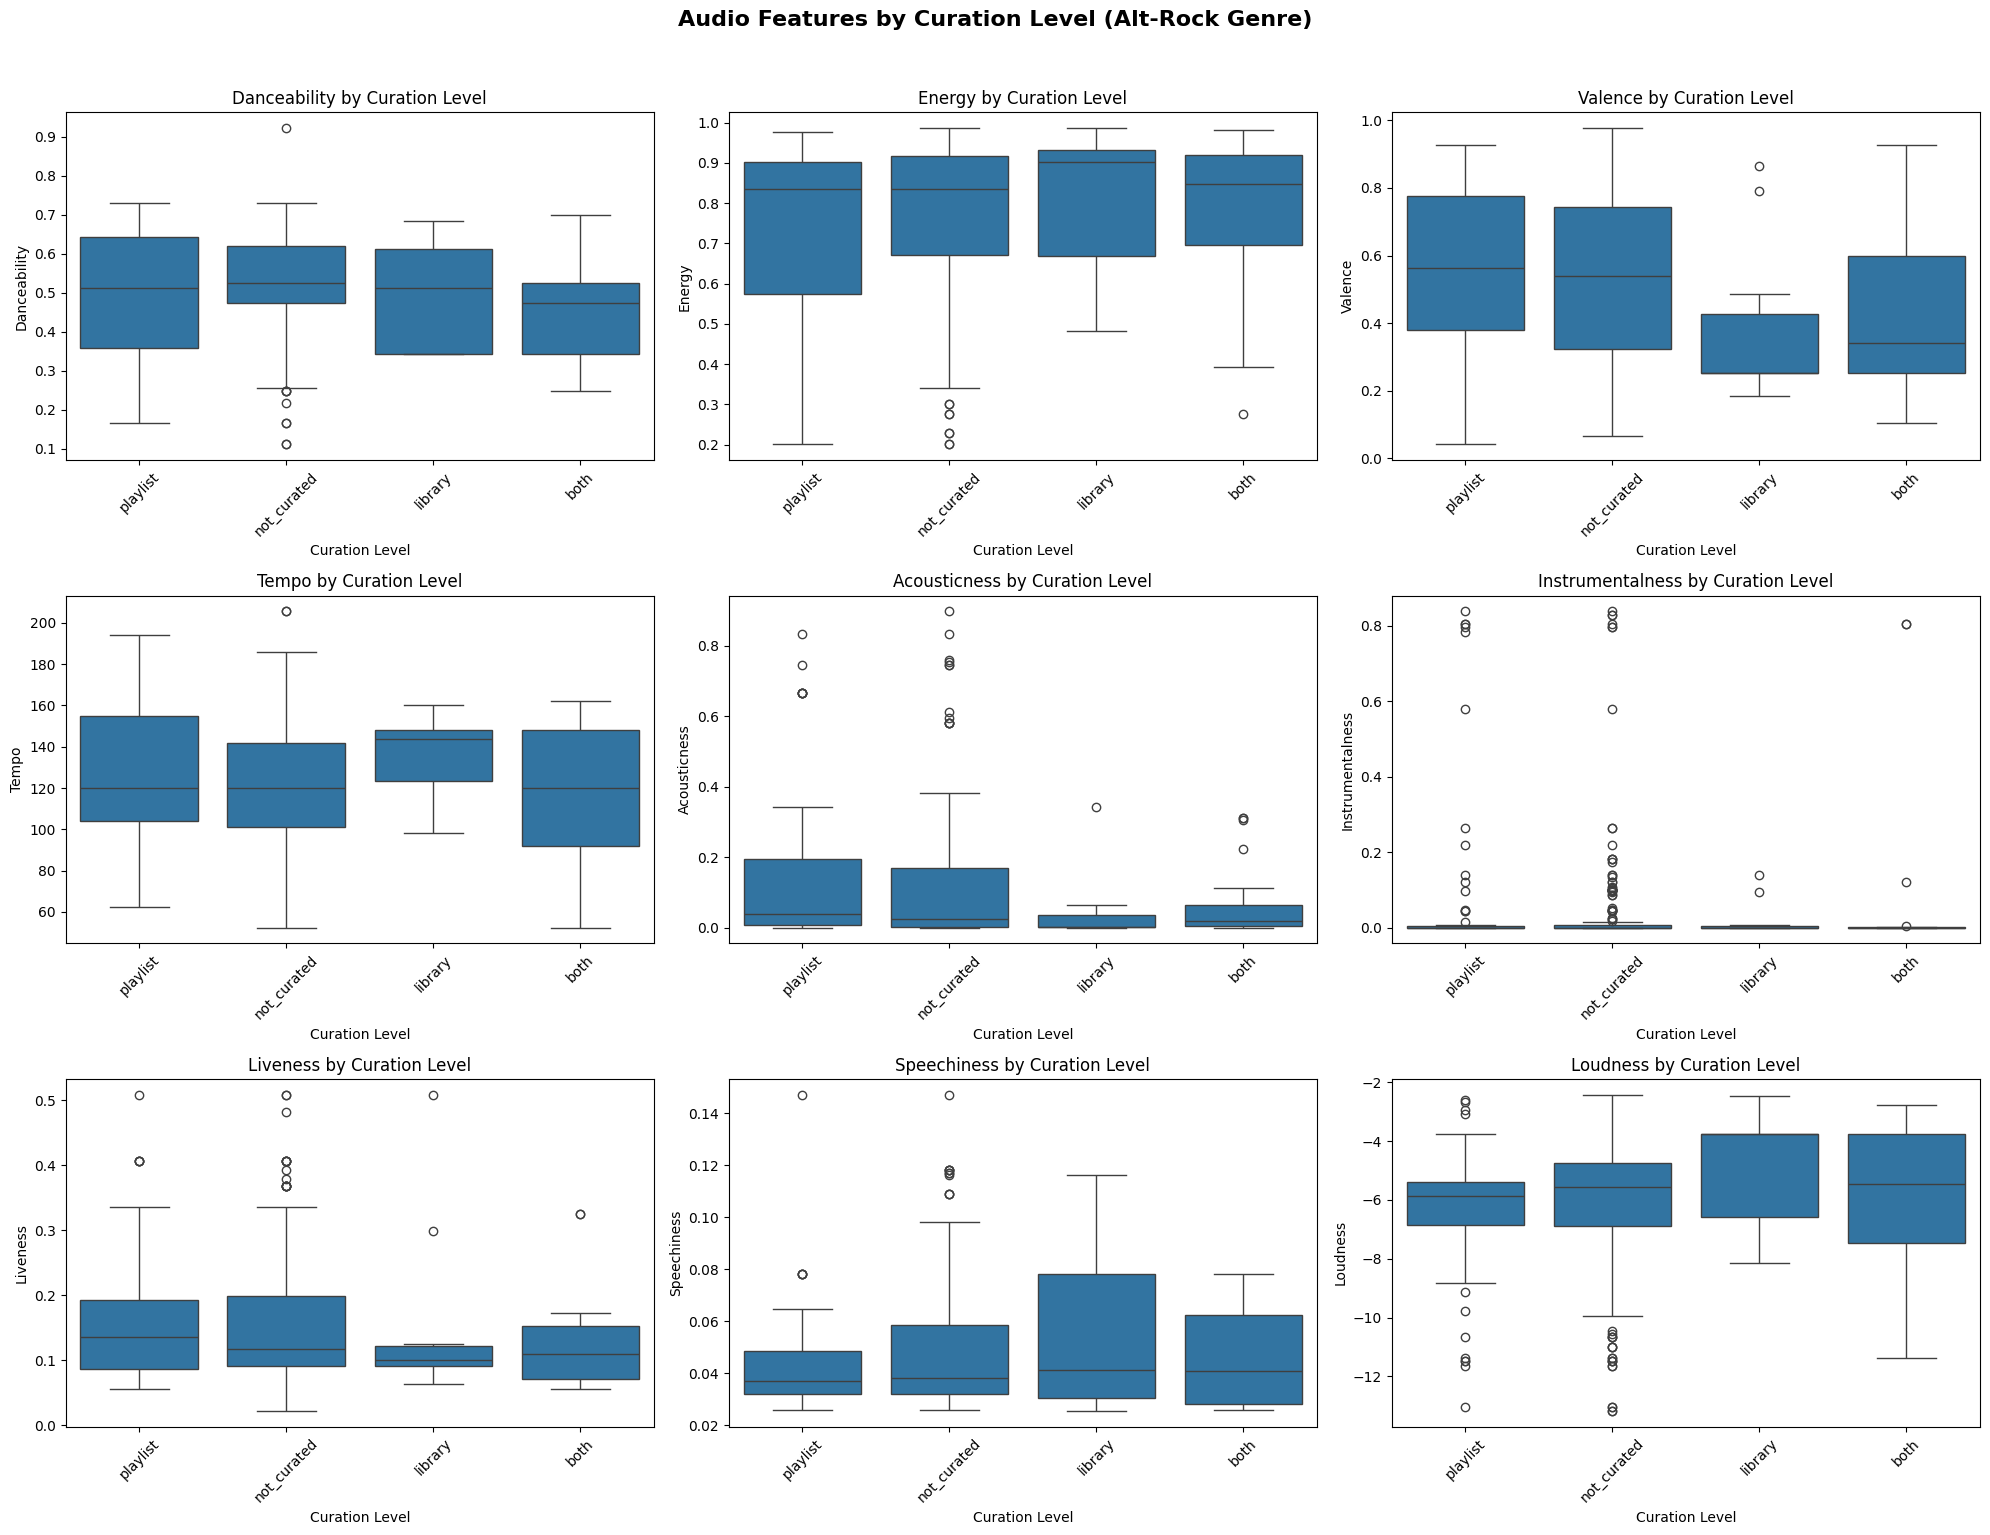

In [ ]:
# Subplots for audio features by curation level, filtered to alt-rock genre only
features = ["danceability", "energy", "valence", "tempo", "acousticness", 
            "instrumentalness", "liveness", "speechiness", "loudness"]

# Filter to study genre only
study_data = full_data[full_data['track_genre'] == 'alt-rock']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x="curation_label", y=feature, data=study_data)
    plt.title(f"{feature.capitalize()} by Curation Level")
    plt.xlabel("Curation Level")
    plt.ylabel(feature.capitalize())
    plt.xticks(rotation=45)
plt.suptitle("Audio Features by Curation Level (Alt-Rock Genre)", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

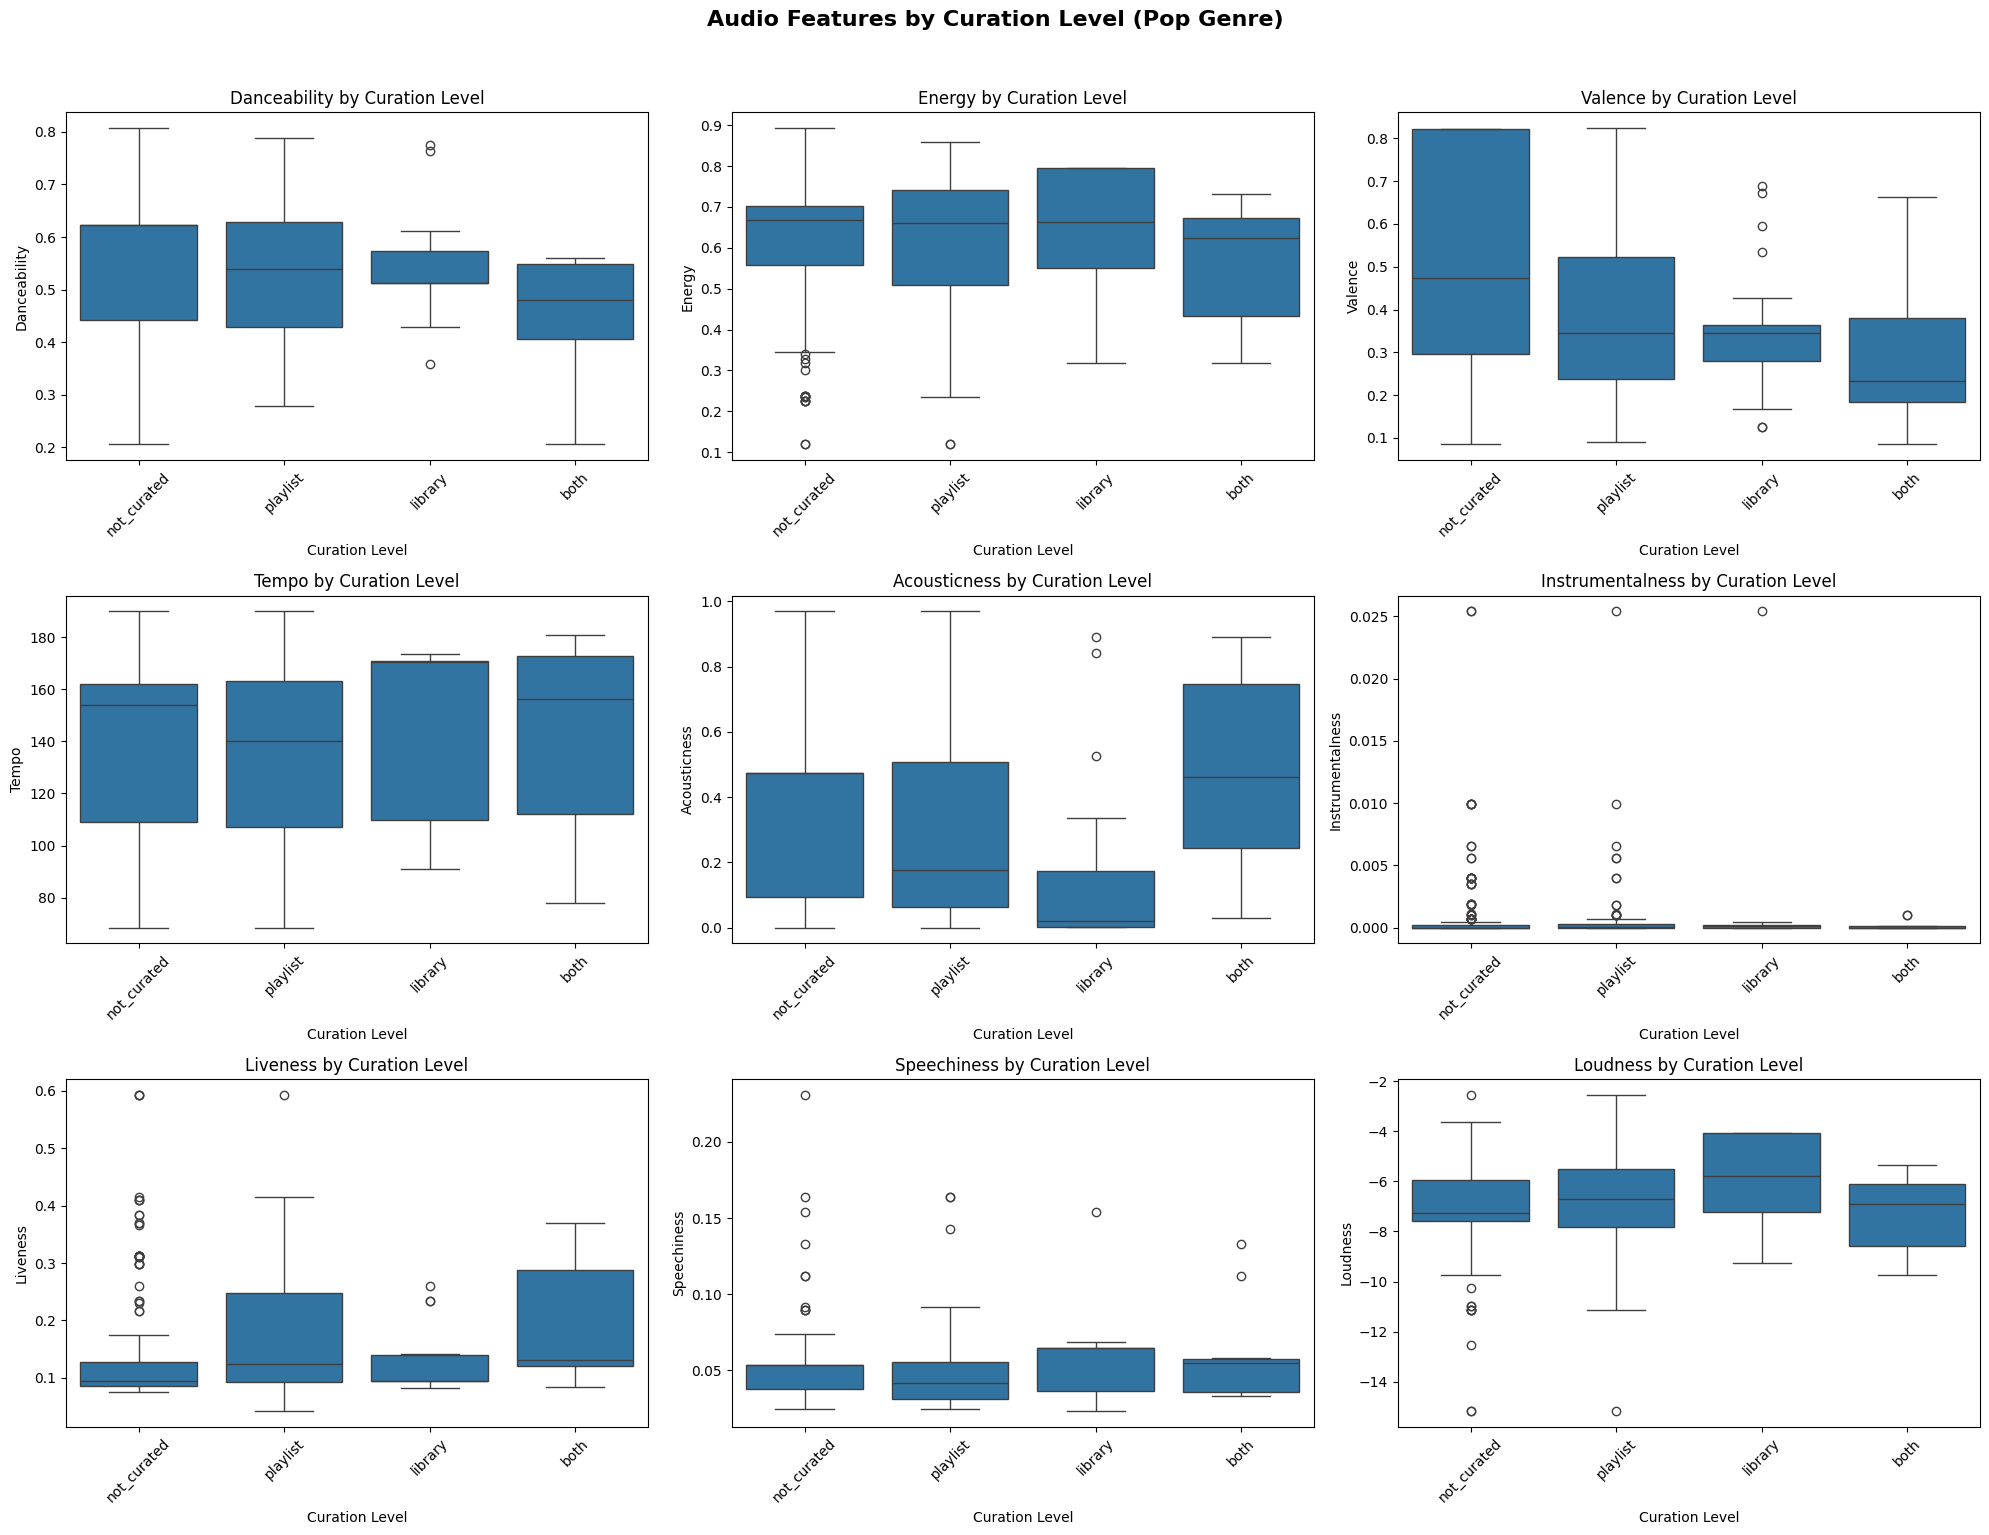

In [135]:
# Filter to pop genre only
study_data = full_data[full_data['track_genre'] == 'pop']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x="curation_label", y=feature, data=study_data)
    plt.title(f"{feature.capitalize()} by Curation Level")
    plt.xlabel("Curation Level")
    plt.ylabel(feature.capitalize())
    plt.xticks(rotation=45)
plt.suptitle("Audio Features by Curation Level (Pop Genre)", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

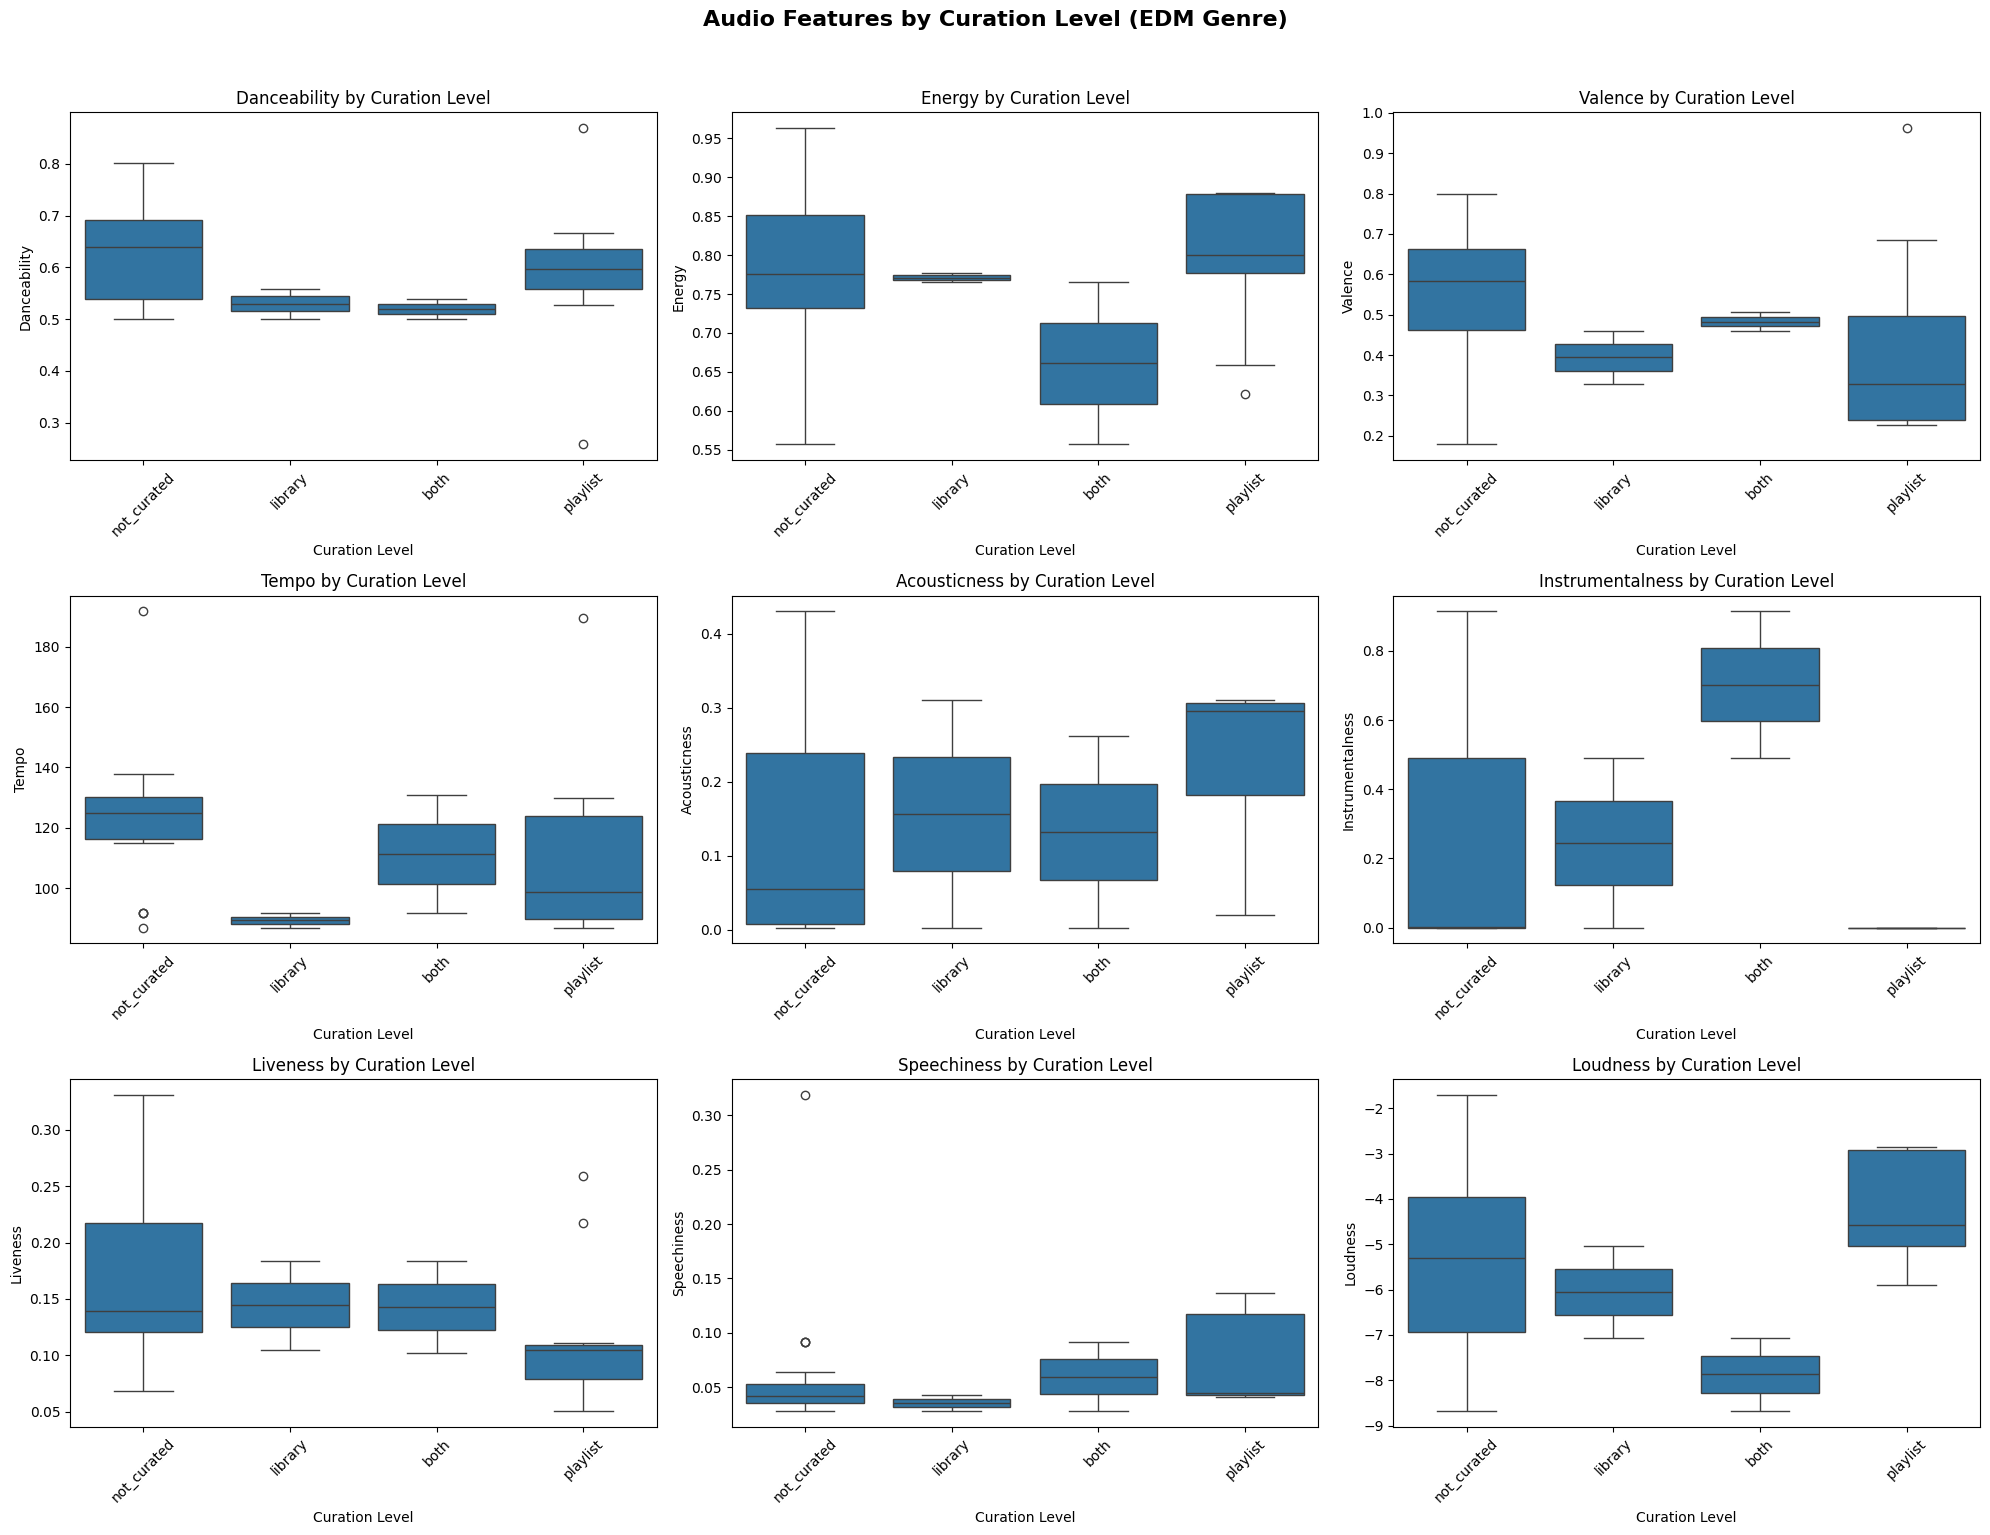

In [136]:
# Filter to edm genre only
study_data = full_data[full_data['track_genre'] == 'edm']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x="curation_label", y=feature, data=study_data)
    plt.title(f"{feature.capitalize()} by Curation Level")
    plt.xlabel("Curation Level")
    plt.ylabel(feature.capitalize())
    plt.xticks(rotation=45)
plt.suptitle("Audio Features by Curation Level (EDM Genre)", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

For different genres, the audio features that show the greatest variability across curation levels vary. For example, liveness, energy, and loudness show the greatest variability and impact for the listeners who enjoy the EDM genre who want to save it to their library or playlist. This is not the case for Pop or Alt-Rock music. This suggests that in terms of recommendations, the weight on each song's audio features needs to be tailored for that specific genre of music they're listening to.

### Genre/Curation Feature Engineering
Developing genre-specific curation thresholds

In [137]:
# Scaler for normalizing feature values before delta calculation
scaler = MinMaxScaler()

# Compute mean feature values per genre per curation level
# Normalize the raw feature values first, then recompute deltas
full_data_norm = full_data.copy()
full_data_norm[features] = scaler.fit_transform(full_data[features].fillna(0))

# Then rerun the groupby and delta calculation on full_data_norm
genre_curation_means_norm = (
    full_data_norm.groupby(['track_genre', 'curation_label'])[features]
    .mean()
    .reset_index()
)

# Pivot so each row is a genre, columns are (feature, curation_level)
genre_pivot = genre_curation_means_norm.pivot(
    index='track_genre', 
    columns='curation_label', 
    values=features
)

# Compute delta between library and not_curated for each feature
deltas = pd.DataFrame(index=genre_pivot.index)
for feat in features:
    try:
        deltas[f'{feat}_delta'] = (
            genre_pivot[(feat, 'library')] - genre_pivot[(feat, 'not_curated')]
        )
    except KeyError:
        pass

# Compute an overall "curation signal strength" per genre (mean absolute delta across all features, normalized)
delta_cols = [c for c in deltas.columns if c.endswith('_delta')]
deltas['signal_strength'] = deltas[delta_cols].abs().mean(axis=1)
deltas = deltas.sort_values('signal_strength', ascending=False)

print("Top genres with strongest curation signal:")
print(deltas['signal_strength'].head(15))

# Heatmap of deltas (library - not_curated) per genre
# Filter to top 20 genres by signal strength for readability
top_genres = deltas.head(20).index

delta_plot = deltas.loc[top_genres, delta_cols].copy()
delta_plot.columns = [c.replace('_delta', '') for c in delta_plot.columns]

# Normalize each feature column to [-1, 1] for cross-feature comparability
delta_plot_norm = delta_plot.apply(
    lambda col: col / col.abs().max() if col.abs().max() > 0 else col
)

Top genres with strongest curation signal:
track_genre
german         0.181389
blues          0.164084
funk           0.156672
electro        0.154606
acoustic       0.127676
anime          0.120767
cantopop       0.118983
french         0.117268
alternative    0.107474
r-n-b          0.103182
rock-n-roll    0.101788
soul           0.101780
chill          0.095116
mandopop       0.090397
rock           0.089251
Name: signal_strength, dtype: float64


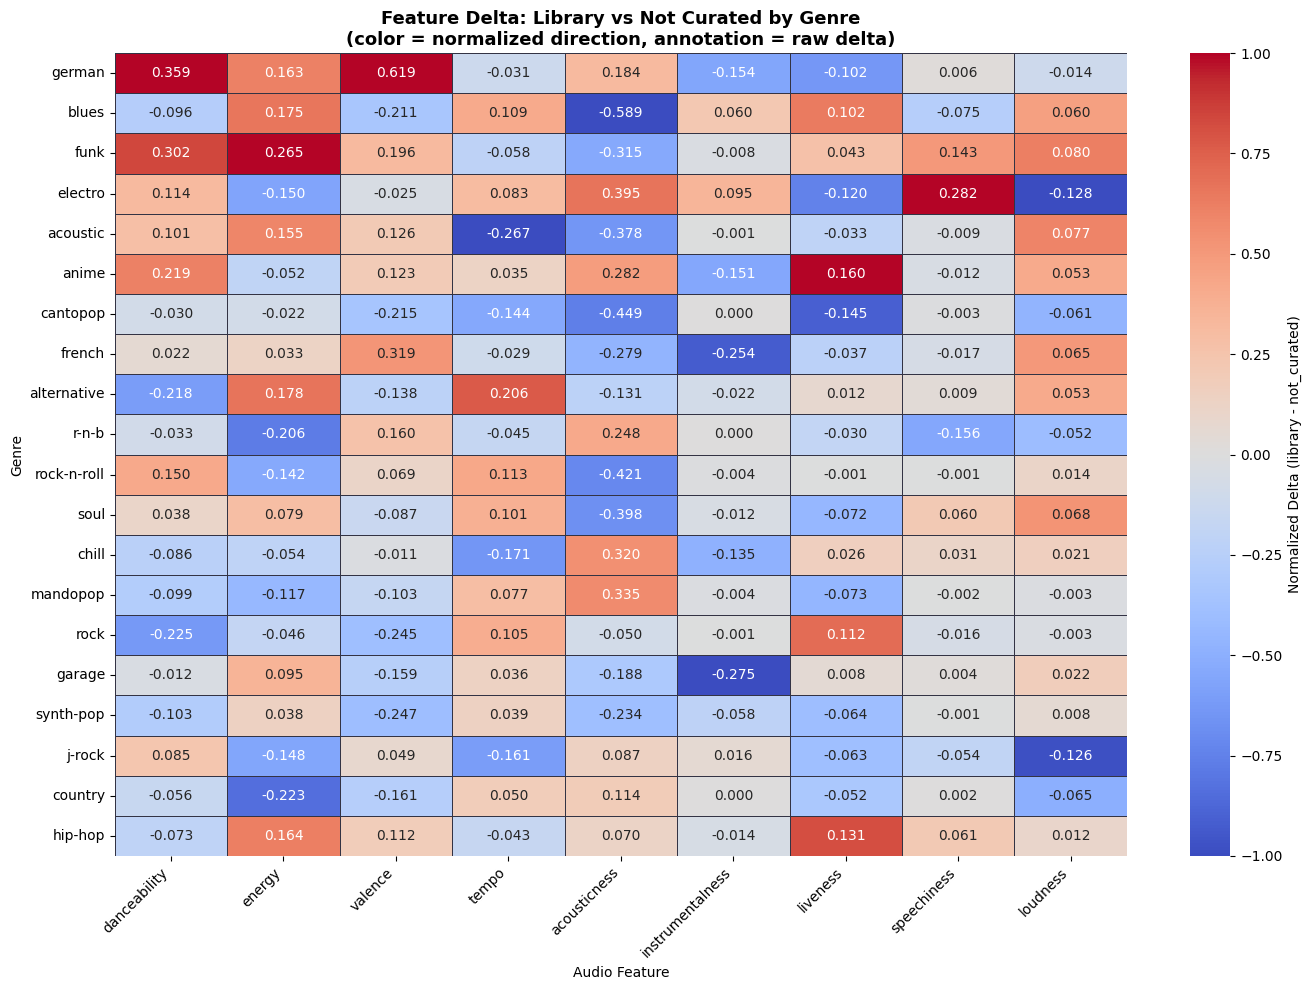

In [138]:
# Visualize as heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    delta_plot_norm,
    cmap='coolwarm', center=0,
    annot=delta_plot.round(3),   # show raw delta values
    fmt='.3f',
    linewidths=0.5, linecolor='#333344',
    cbar_kws={'label': 'Normalized Delta (library - not_curated)'}
)
plt.title('Feature Delta: Library vs Not Curated by Genre\n(color = normalized direction, annotation = raw delta)',
          fontsize=13, fontweight='bold')
plt.xlabel('Audio Feature')
plt.ylabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

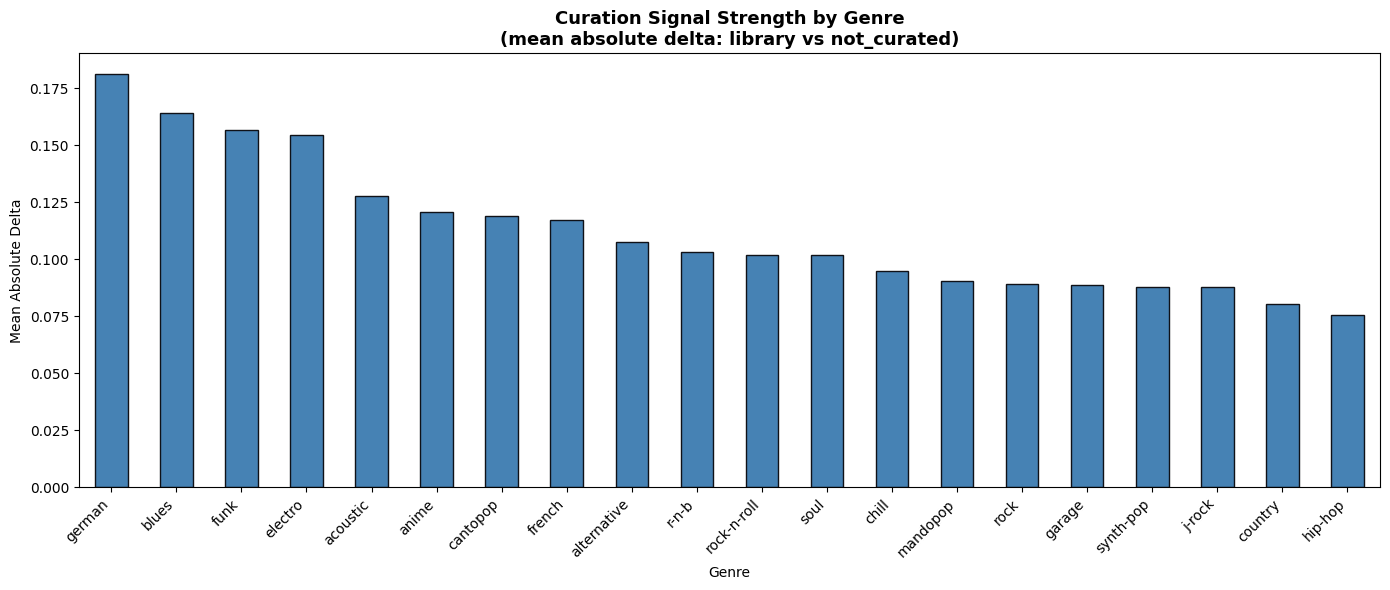

In [139]:
# Bar chart of overall signal strength by genre
plt.figure(figsize=(14, 6))
deltas['signal_strength'].head(20).plot(
    kind='bar', color='steelblue', edgecolor='#0F1117'
)
plt.title('Curation Signal Strength by Genre\n(mean absolute delta: library vs not_curated)',
          fontsize=13, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Mean Absolute Delta')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Less popular genres tend to on avg have a larger delta between non-curated songs and songs added to the library in terms of overall feature differences. This points towards the algorithm having less exposure to these songs or fewer number of tracks, as it struggles to suggest songs that people truly enjoy and end up saving.